In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import os
from tqdm import tqdm
import sys
import time
import json
import pickle
import random
import re

import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap

In [39]:
spike_inf = pd.read_csv("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/022522/spike_inf.tsv", sep = '\t', index_col=0)
with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/122022/neuron_inf.pkl", 'rb') as f:
    neuron_inf = pickle.load(f)

In [40]:
neuron_inf

,Neuron,position_1,position_2,position_waveform,channel_id,cluster,tract_channel
0,Neuron_1,25.292154,25.813559,"[6.6664176, 6.7331996, 5.2064342, 3.996775, 2....","[1, 3, 7, 9, 11]","[1, 5]",9
1,Neuron_9,7.971443,59.500652,"[3.447764, 2.7675045, -1.8073038, -3.4724295, ...","[1, 3, 5, 7, 9]",9,5
2,Neuron_10,33.888977,75.588951,"[2.915803, 2.2125573, -0.86929613, -0.43700722...","[3, 5, 7, 9, 11]",10,7
3,Neuron_11,39.377281,85.288666,"[2.2525184, 6.4831934, -5.591465, -6.0042205, ...","[3, 5, 7, 9, 11]",11,7
4,Neuron_12,8.199291,56.895691,"[5.060994, 6.189023, 3.188424, 2.1998103, 3.09...","[1, 3, 5, 7, 9]",12,5
5,Neuron_13,6.049122,73.681229,"[12.671591, 12.469951, 7.881517, 9.029767, 11....","[1, 3, 5, 7, 9]",13,5
6,Neuron_15,165.589355,228.950089,"[-8.1525755, -9.303494, -10.994559, -13.857547...","[13, 15, 17, 21, 23]",15,13
7,Neuron_16,164.949738,229.181488,"[6.3254123, 5.080643, 3.254955, 3.7410996, 3.5...","[13, 15, 17, 21, 23]",16,13
8,Neuron_17,160.421921,222.957535,"[1.8183105, 0.7007255, -3.8096726, 1.7925946, ...","[13, 15, 17, 21, 23]",17,13
9,Neuron_19,181.249756,246.263626,"[4.8082986, 4.1058593, 2.428278, 2.5023496, 2....","[13, 15, 17, 19, 21, 23]",19,21


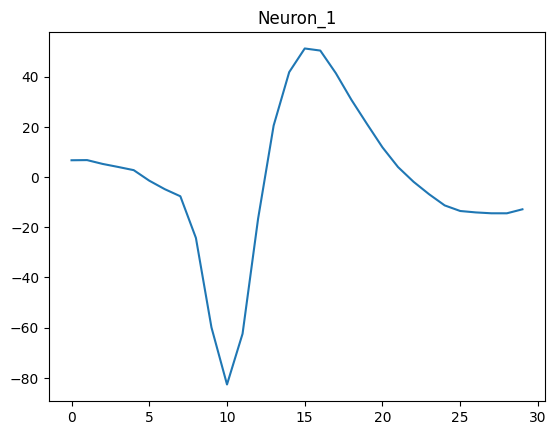

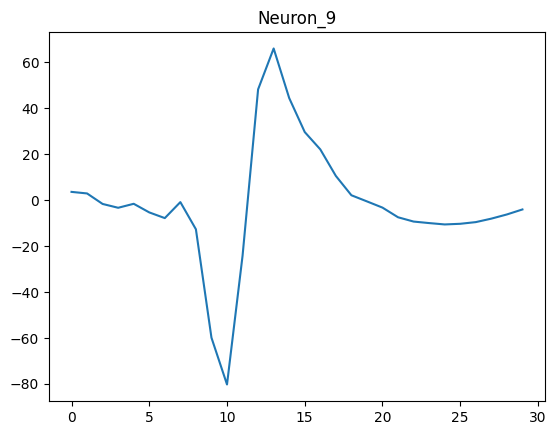

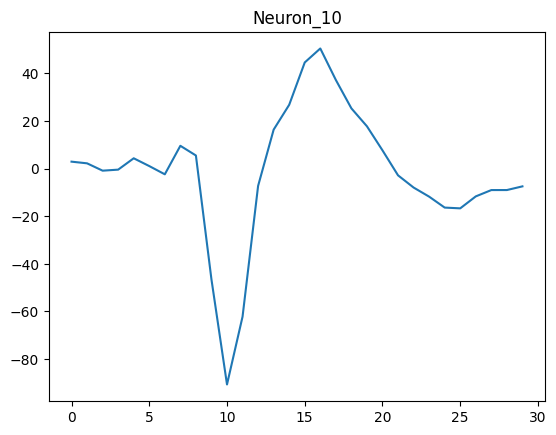

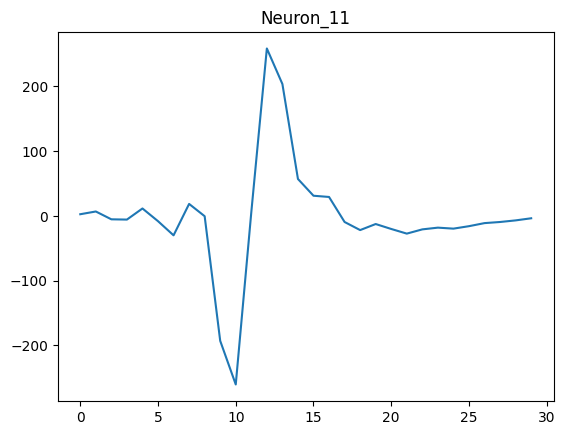

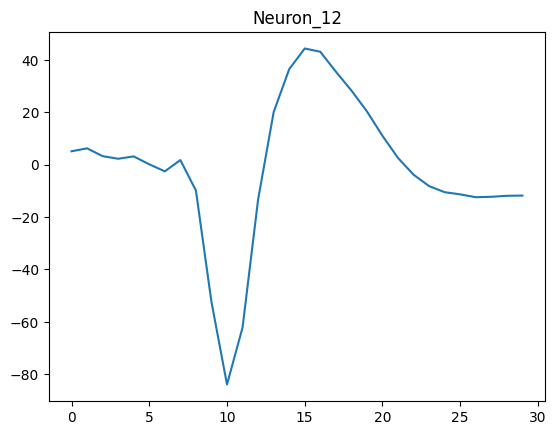

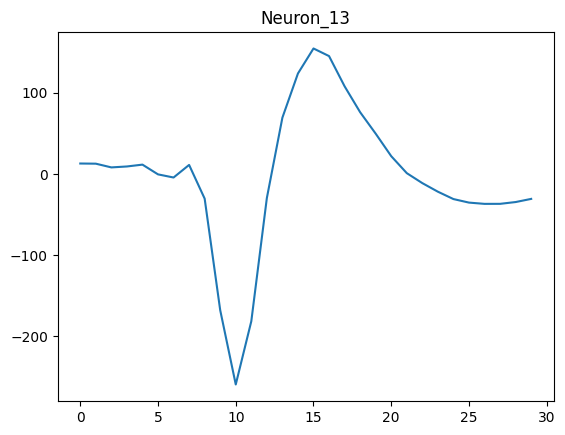

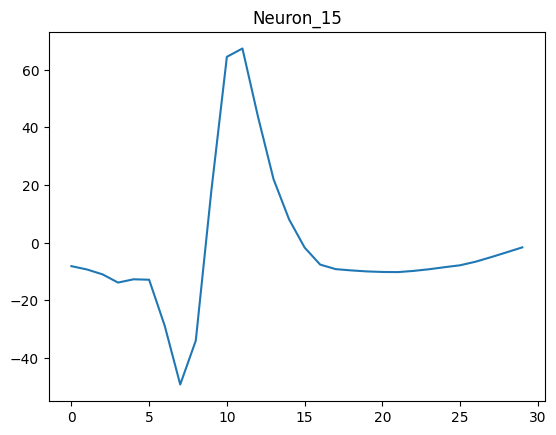

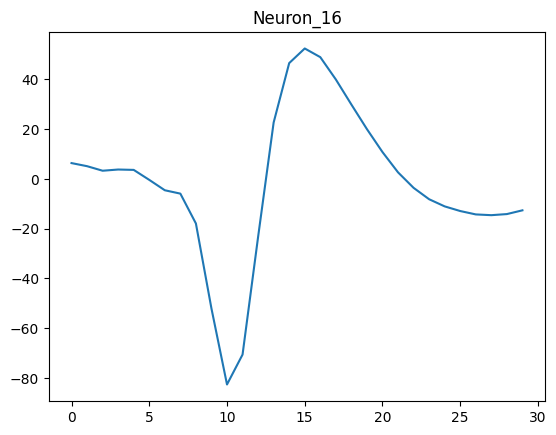

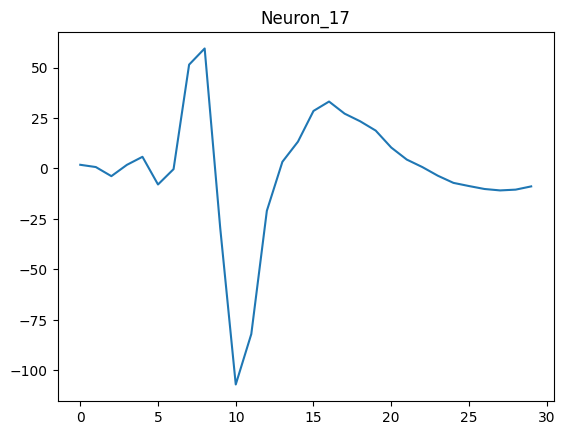

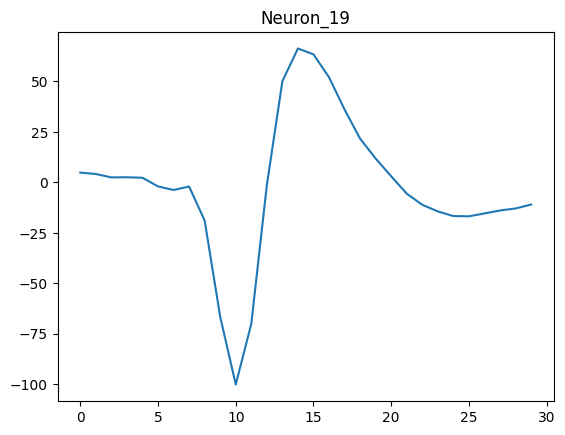

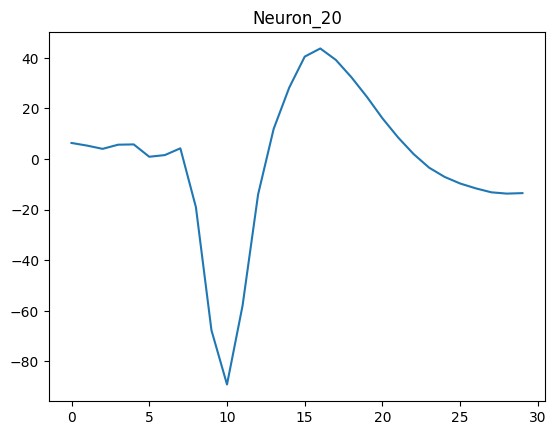

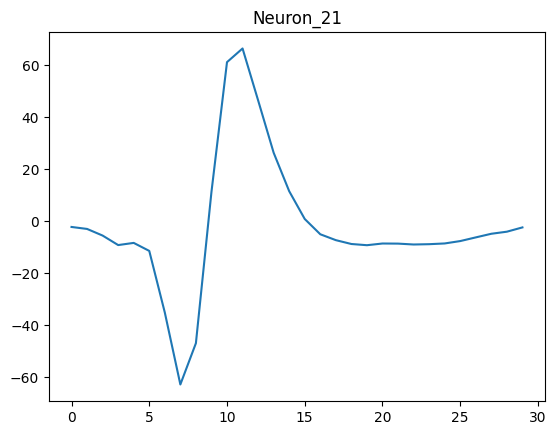

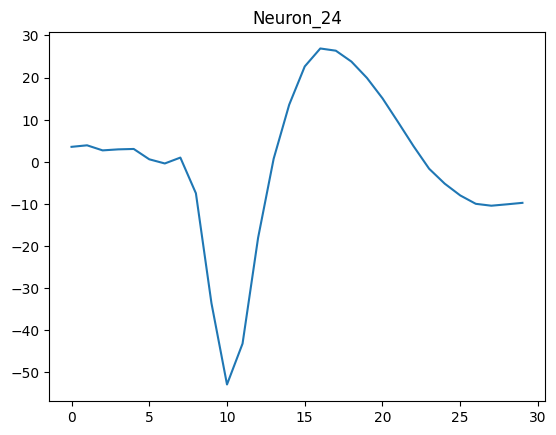

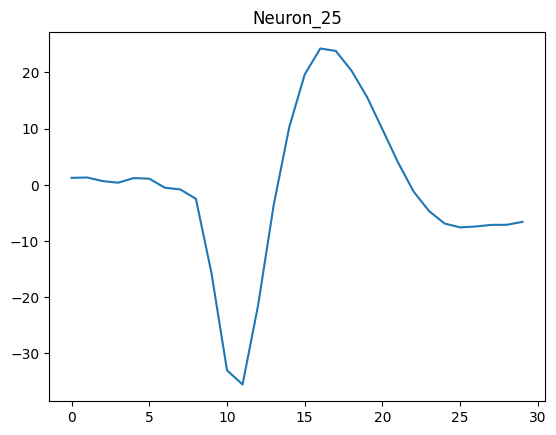

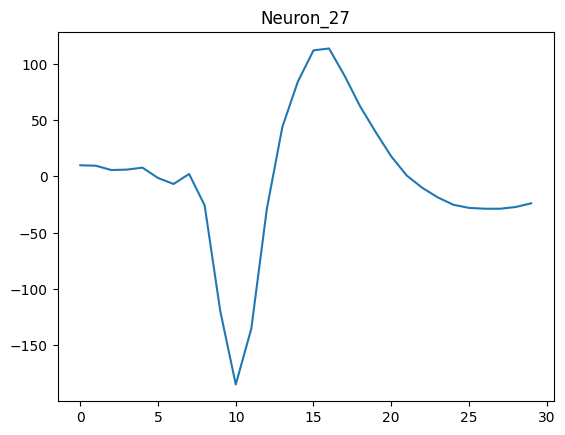

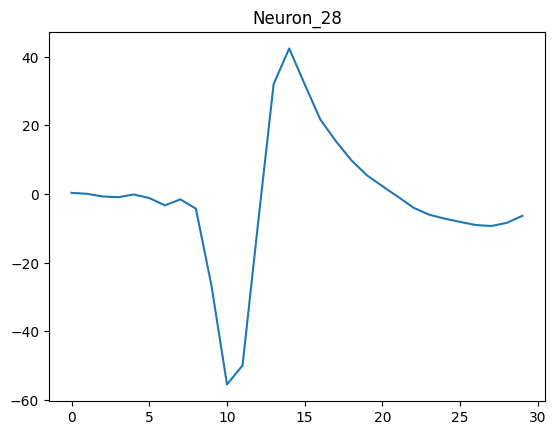

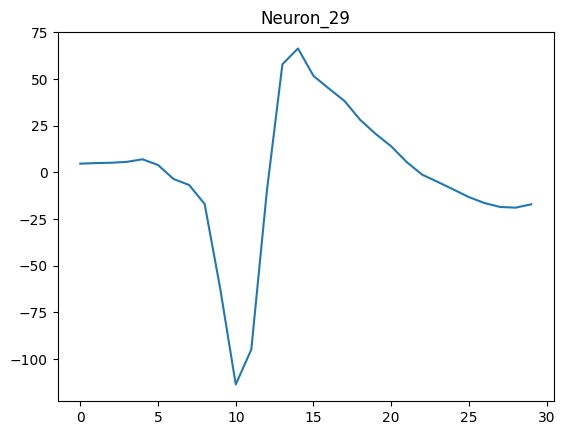

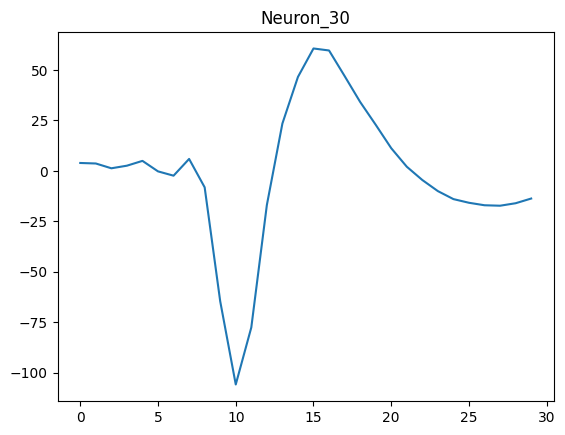

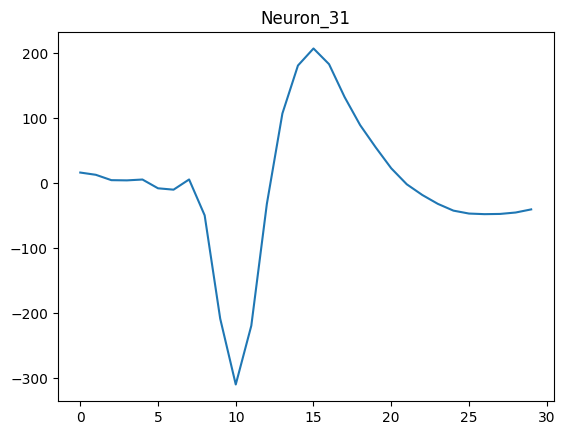

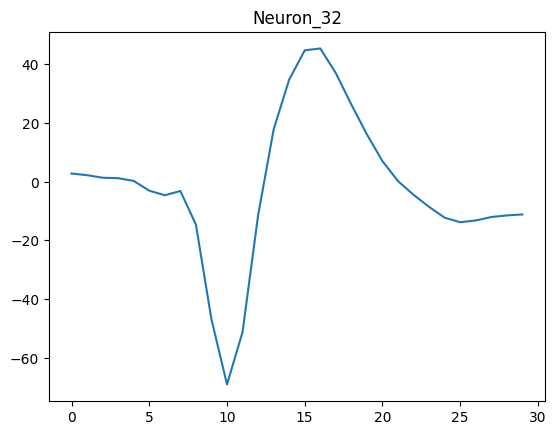

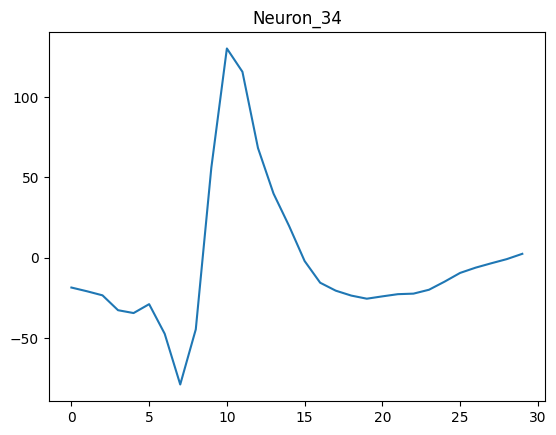

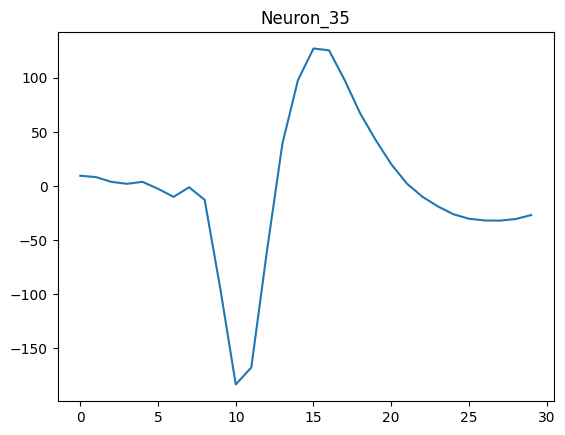

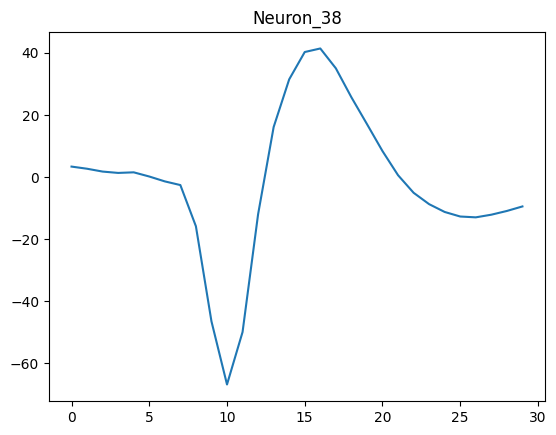

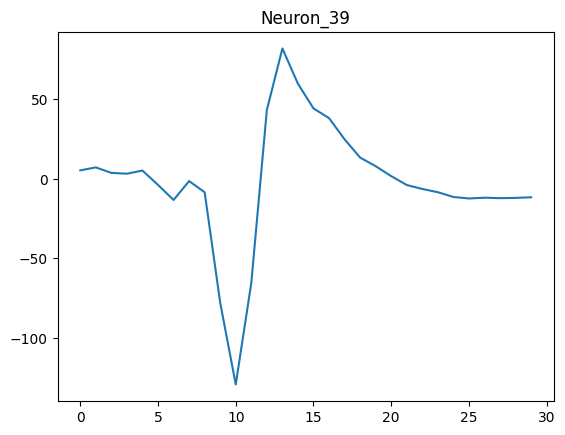

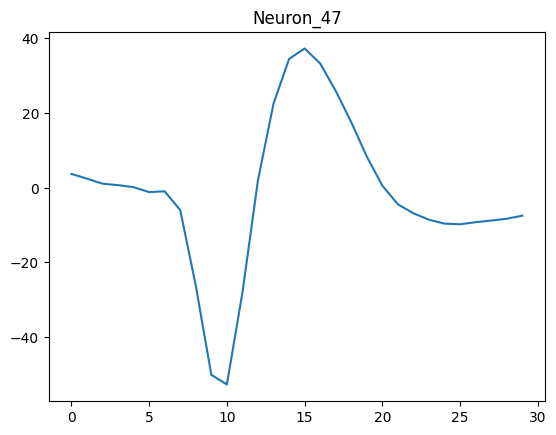

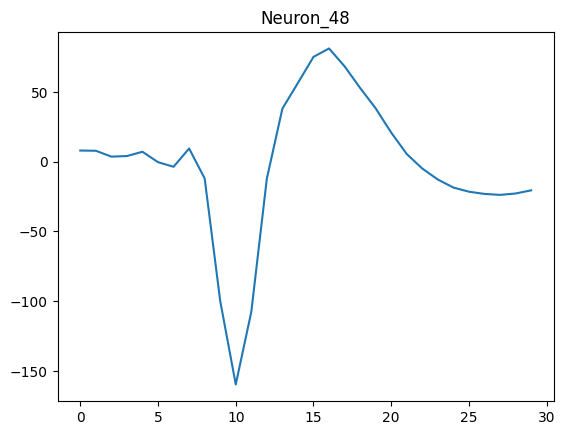

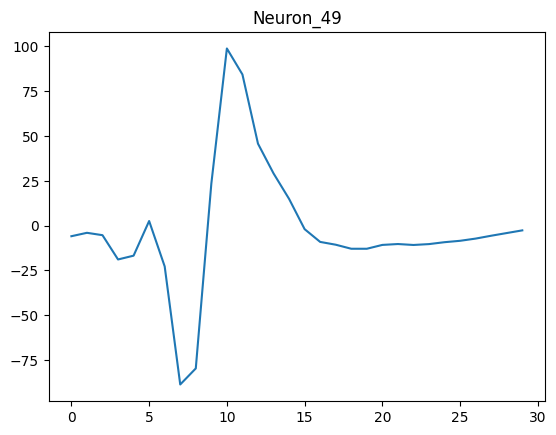

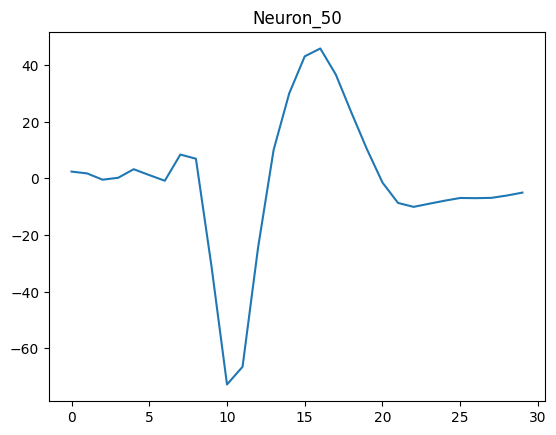

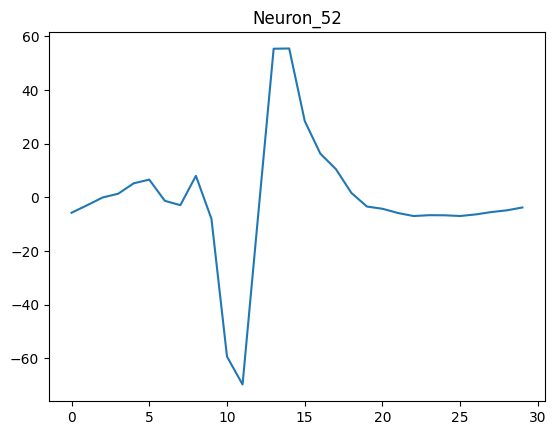

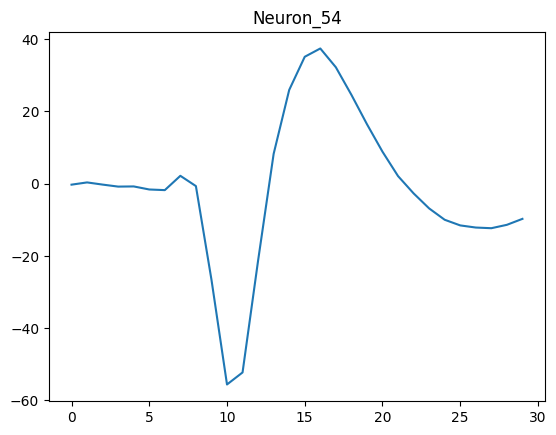

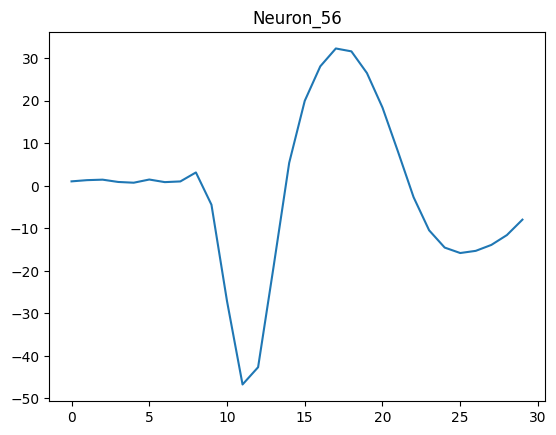

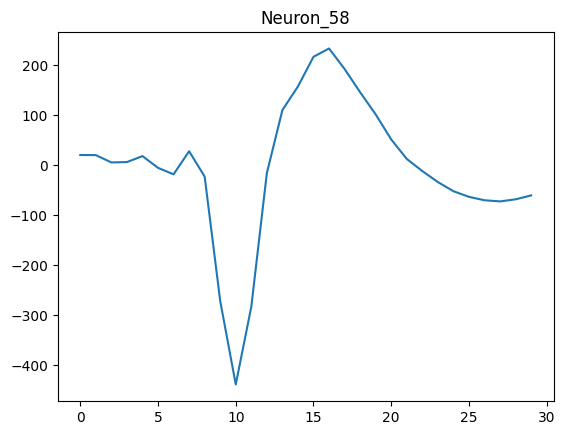

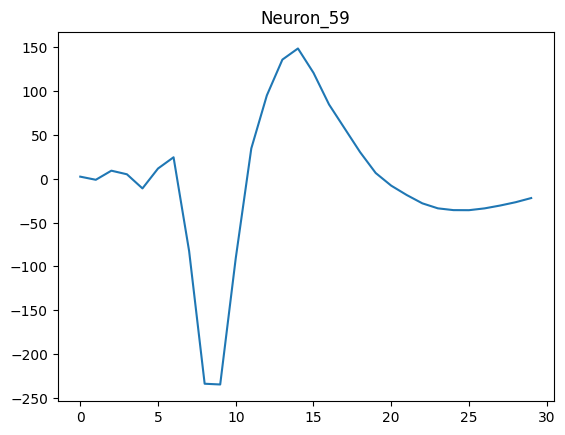

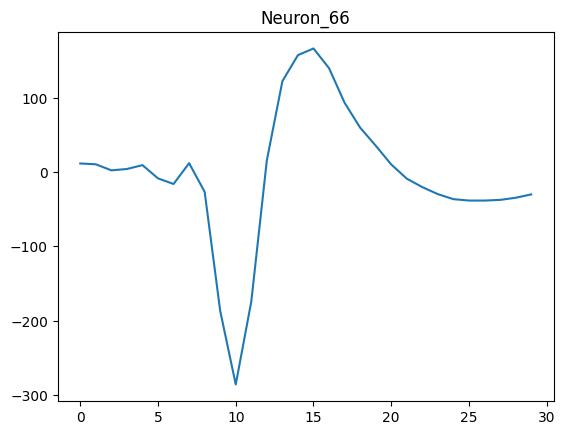

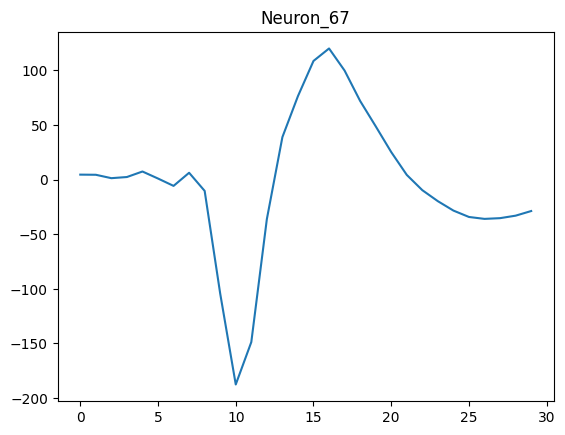

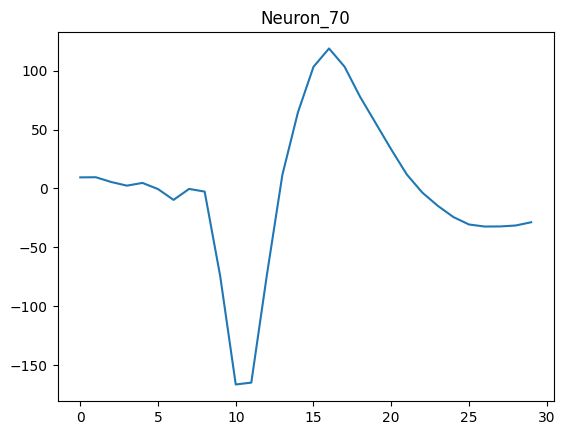

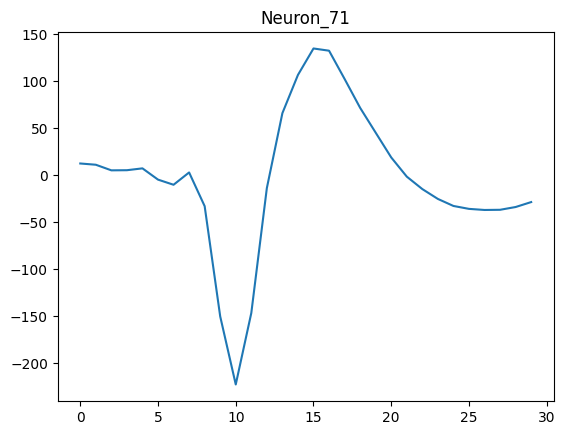

In [41]:
for i in range(len(neuron_inf)):
    plt.figure()
    sns.lineplot(neuron_inf['position_waveform'][i].T)
    plt.title(neuron_inf['Neuron'][i])

In [4]:
neuron_inf

,Neuron,position_1,position_2,position_waveform,channel_id,cluster,tract_channel
0,Neuron_3,17.512636,35.752811,"[3.2526555, 2.7949586, 1.4568826, -0.48819783,...","[1, 3, 5, 7, 9, 11]",3,9
1,Neuron_9,22.432472,14.698872,"[2.737996, 3.5611422, 2.9425592, 3.0211866, 2....","[1, 3, 7, 9, 11]",9,11
2,Neuron_12,4.191727,70.332146,"[12.928641, 12.210501, 5.473361, 5.4525356, 9....","[1, 3, 5, 7, 9]",12,5
3,Neuron_13,5.375986,51.971687,"[-0.8723568, -0.45704898, -1.7247455, -1.56382...","[1, 3, 5, 7, 9]",13,5
4,Neuron_14,27.786940,63.619541,"[-0.07175204, -0.14420961, -0.9821535, -0.8999...","[3, 5, 7, 9, 11]",14,7
5,Neuron_15,183.531006,228.725189,"[6.4588623, 6.01891, 4.904146, 5.8878765, 5.01...","[13, 15, 19, 21, 23]",15,23
6,Neuron_18,181.585281,245.019363,"[0.40753877, 1.6416914, 0.80666125, 0.52655894...","[13, 15, 17, 19, 21, 23]",18,21
7,Neuron_24,166.596619,229.876434,"[4.1142144, 2.8329086, 0.55609006, -0.4578938,...","[13, 15, 17, 21, 23]",24,13
8,Neuron_28,183.083389,266.539154,"[0.7452692, 1.3823476, 1.2196943, 1.1886629, 1...","[15, 17, 19, 21, 23]",28,19
9,Neuron_29,163.431290,268.223114,"[4.420608, 4.2250323, 2.496528, 2.0893927, 3.6...","[13, 15, 17, 19, 21]",29,17


In [13]:
# 定义5组标准的channel_id
standard_groups = [
    [1, 3, 5, 7, 9, 11],
    [0, 2, 4, 6, 8, 10],
    [13, 15, 17, 19, 21, 23],
    [12, 14, 16, 18, 20, 22],
    [24, 25, 26, 27, 28, 29]
]

def find_matching_group(channel_id, standard_groups):
    """
    找到与给定channel_id最匹配的标准组
    返回匹配的标准组
    """
    channel_id_set = set(channel_id)
    best_match = None
    max_overlap = 0
    
    for group in standard_groups:
        group_set = set(group)
        overlap = len(channel_id_set & group_set)
        if overlap > max_overlap:
            max_overlap = overlap
            best_match = group
    
    return best_match

# 补全channel_id
for i in range(len(neuron_inf)):
    current_channel_id = neuron_inf['channel_id'].iloc[i]
    
    # 如果已经是列表，直接使用；如果是其他格式，转换为列表
    if not isinstance(current_channel_id, list):
        current_channel_id = list(current_channel_id) if hasattr(current_channel_id, '__iter__') else [current_channel_id]
    
    # 如果channel_id长度小于6，需要补全
    if len(current_channel_id) < 6:
        # 找到最匹配的标准组
        matched_group = find_matching_group(current_channel_id, standard_groups)
        
        if matched_group:
            # 补全缺失的channel_id
            current_set = set(current_channel_id)
            missing_channels = [ch for ch in matched_group if ch not in current_set]
            
            # 将缺失的channel_id添加到当前列表中
            neuron_inf.at[i, 'channel_id'] = sorted(current_channel_id + missing_channels)
        else:
            print(f"警告: Neuron {i} 的 channel_id {current_channel_id} 无法匹配到任何标准组")
    elif len(current_channel_id) > 6:
        # 如果超过6个，可能需要截断或处理
        print(f"警告: Neuron {i} 的 channel_id 有 {len(current_channel_id)} 个，超过6个: {current_channel_id}")

In [14]:
recording_raw = se.read_blackrock(file_path='/media/ubuntu/sda/data/mouse6/ns4/natural_image/mouse6_022522_natural_image_001.ns4')
recording_recorded = recording_raw.remove_channels(["98", '31', '32'])

recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
recording_f = spre.common_reference(recording_f, reference="global", operator="median")

In [15]:
# 阈值检测策略（增强版：检测负值peak和正值peak）
def detect_local_minimum_in_window(data, window_size=20, std_multiplier_min=2, std_multiplier_max=2, channel_groups=None):
    """
    在每个滑动窗口范围内检测局部最小值和最大值的索引
    
    参数:
        data: numpy数组，形状为 (n_channels, time_length)
        window_size: 滑动窗口大小
        std_multiplier_min: 最小值检测的标准差倍数（用于负值peak）
        std_multiplier_max: 最大值检测的标准差倍数（用于正值peak）
        channel_groups: 通道组列表，每个组是一个channel_id列表。如果为None，返回每个通道的结果
    
    返回:
        如果channel_groups为None: dict，键为通道索引，值为该通道检测到的索引列表
        如果channel_groups不为None: dict，键为group索引，值为合并后该组所有通道的检测结果（去重并排序）
    """
    def is_peak(data_array, idx, peak_type='min'):
        """
        判断索引idx是否是peak（局部极值点）
        peak_type: 'min' 表示最小值peak，'max' 表示最大值peak
        """
        if idx <= 0 or idx >= len(data_array) - 1:
            return False
        
        if peak_type == 'min':
            # 对于最小值peak，左右两侧的值都应该大于当前值
            return data_array[idx] < data_array[idx-1] and data_array[idx] < data_array[idx+1]
        else:  # peak_type == 'max'
            # 对于最大值peak，左右两侧的值都应该小于当前值
            return data_array[idx] > data_array[idx-1] and data_array[idx] > data_array[idx+1]
    
    # 首先获取每个通道的检测结果
    channel_results = {}
    
    for channel_idx, row in enumerate(data):
        detected_indices = []
        row = row.astype(np.float32)
        row_mean = np.mean(row)
        row_std = np.std(row)
        threshold_min = row_mean - std_multiplier_min * row_std  # 负值阈值
        threshold_max = row_mean + std_multiplier_max * row_std  # 正值阈值
        
        # 检测局部最小值（负值peak）
        minima_indices = []
        for start in range(0, len(row), window_size):
            end = min(start + window_size, len(row))
            window = row[start:end]
            
            if len(window) > 0:
                local_min_index = start + np.argmin(window)
                local_min_value = row[local_min_index]
                
                # 检查是否是peak且低于阈值
                if local_min_value < threshold_min and is_peak(row, local_min_index, 'min'):
                    minima_indices.append(local_min_index)
        
        # 检测局部最大值（正值peak）
        maxima_indices = []
        for start in range(0, len(row), window_size):
            end = min(start + window_size, len(row))
            window = row[start:end]
            
            if len(window) > 0:
                local_max_index = start + np.argmax(window)
                local_max_value = row[local_max_index]
                
                # 检查是否是peak且高于阈值
                if local_max_value > threshold_max and is_peak(row, local_max_index, 'max'):
                    detected_indices.append(local_max_index)

        for min_idx in minima_indices:
            if min_idx not in detected_indices:
                detected_indices.append(min_idx)
        
        # 去重并排序
        channel_results[channel_idx] = sorted(list(set(detected_indices)))
    
    # 如果没有指定channel_groups，返回每个通道的结果
    if channel_groups is None:
        return channel_results
    
    # 按channel_groups合并结果并提取窗口
    group_results = {}
    group_windows = {}
    
    for group_idx, group_channels in enumerate(channel_groups):
        merged_indices = []
        for channel_id in group_channels:
            if channel_id in channel_results:
                merged_indices.extend(channel_results[channel_id])
        # 去重并排序
        unique_indices = sorted(list(set(merged_indices)))
        group_results[group_idx] = unique_indices
        
        # 提取窗口：只提取该group对应通道的窗口数据
        if len(unique_indices) > 0:
            # 过滤边界附近的spike（确保可以提取完整的窗口）
            left_sample = 30
            right_sample = 30
            valid_indices = [
                idx for idx in unique_indices 
                if idx >= left_sample and idx < data.shape[1] - right_sample
            ]
            
            # 只保留valid_indices，确保indices和windows长度一致
            group_results[group_idx] = valid_indices
            
            if len(valid_indices) > 0:
                # 提取窗口：对于每个spike，提取该group所有通道的窗口
                windows = []
                for idx in valid_indices:
                    # 提取 [idx - 10, idx + 20)，共30个时间点
                    window = data[group_channels, idx - left_sample:idx + right_sample]
                    windows.append(window)
                
                # 转换为numpy数组，形状为 (n_spikes, n_channels, window_length)
                group_windows[group_idx] = np.array(windows)
            else:
                group_windows[group_idx] = np.array([]).reshape(0, len(group_channels), 30)
        else:
            group_windows[group_idx] = np.array([]).reshape(0, len(group_channels), 30)
    
    # 返回时间点索引和窗口数据
    return {
        'indices': group_results,
        'windows': group_windows
    }

def extract_windows(data, indices, window_size=30):
    """
    根据给定的时间点索引提取窗口
    与train_spike_pipeline.py保持一致：
    - left_sample = 10 (spike前10个采样点)
    - right_sample = 20 (spike后20个采样点)
    - 总共30个采样点: [spike_time - 10, spike_time + 19]
    """
    n_channels, time_length = data.shape
    left_sample = 30   # 与train_spike_pipeline.py保持一致
    right_sample = 30  # 与train_spike_pipeline.py保持一致
    
    # 验证边界
    if np.any(indices < left_sample) or np.any(indices >= time_length - right_sample):
        raise ValueError("Some indices are out of bounds for the given window size.")

    windows = []
    for idx in indices:
        # 提取 [idx - 10, idx + 20)，共30个时间点
        window = data[:, idx - left_sample:idx + right_sample]
        windows.append(window)

    windows = np.array(windows)
    return windows

# 使用阈值检测策略检测spike
# 参数与eval_spike_pipeline.py完全一致
std_multiplier_min = 2.4  # 最小值检测的标准差倍数（用于负值peak）
std_multiplier_max = 2.7  # 最大值检测的标准差倍数（用于正值peak）
window_size = 10          # 滑动窗口大小

# 从neuron_inf中提取唯一的channel_id组（用于合并检测结果）
# 将每个channel_id列表转换为tuple以便作为dict的key
channel_id_tuples = [tuple(sorted(ch_id)) if isinstance(ch_id, list) else tuple([ch_id]) 
                      for ch_id in neuron_inf['channel_id'].values]
unique_channel_groups = []
seen = set()
for ch_tuple in channel_id_tuples:
    if ch_tuple not in seen:
        seen.add(ch_tuple)
        unique_channel_groups.append(list(ch_tuple))

channel_groups = unique_channel_groups


In [16]:
# 分chunk读取recording数据并进行阈值检测（减少内存占用）
# 只处理前200秒的数据
print("开始分chunk阈值检测（仅处理前200秒）...")

# 获取recording的采样率和通道数
sampling_rate = recording_f.get_sampling_frequency()
n_channels = recording_f.get_num_channels()
print(f"采样率: {sampling_rate} Hz, 通道数: {n_channels}")

# 计算200秒对应的采样点数
duration_seconds = 200
max_frames = int(duration_seconds * sampling_rate)
total_frames = recording_f.get_num_frames()
actual_frames = min(max_frames, total_frames)

print(f"Recording总长度: {total_frames} 采样点 ({total_frames/sampling_rate:.2f} 秒)")
print(f"将处理前 {actual_frames} 采样点 ({actual_frames/sampling_rate:.2f} 秒)")

# 设置chunk大小（可以根据内存情况调整，单位：采样点数）
chunk_size = 100000  # 每次处理10万个采样点
n_chunks = int(np.ceil(actual_frames / chunk_size))
print(f"Chunk大小: {chunk_size} 采样点, 共 {n_chunks} 个chunks")

# 初始化结果存储（按group存储所有检测到的时间点和窗口数据，保持一一对应）
all_group_times_windows = {group_idx: [] for group_idx in range(len(channel_groups))}

# 分chunk处理
with tqdm(total=n_chunks, desc="处理chunks", unit="chunk") as pbar:
    for chunk_idx in range(n_chunks):
        start_frame = chunk_idx * chunk_size
        end_frame = min((chunk_idx + 1) * chunk_size, actual_frames)
        
        # 读取当前chunk的数据
        chunk_data = recording_f.get_traces(start_frame=start_frame, end_frame=end_frame).astype(np.float32)
        
        # 对当前chunk进行阈值检测（返回包含indices和windows的dict）
        chunk_results = detect_local_minimum_in_window(
            chunk_data.T,
            window_size=window_size,
            std_multiplier_min=std_multiplier_min,
            std_multiplier_max=std_multiplier_max,
            channel_groups=channel_groups
        )
        
        # 处理每个group的结果
        for group_idx in range(len(channel_groups)):
            # 获取chunk内的索引和窗口
            chunk_indices = chunk_results['indices'][group_idx]
            chunk_windows = chunk_results['windows'][group_idx]
            
            # 将检测到的时间点转换为全局时间（加上start_frame偏移）
            for i, local_idx in enumerate(chunk_indices):
                global_time = local_idx + start_frame
                window = chunk_windows[i] if i < len(chunk_windows) else None
                # 将时间点和窗口数据配对存储
                all_group_times_windows[group_idx].append((global_time, window))
        
        pbar.update(1)
        pbar.set_postfix({
            '当前chunk': f"{chunk_idx+1}/{n_chunks}",
            '进度': f"{(chunk_idx+1)/n_chunks*100:.1f}%"
        })

# 合并所有chunk的结果（去重并排序，保持时间点和窗口数据一一对应）
print("\n合并所有chunk的检测结果...")
threshold_results = {}
threshold_windows = {}
for group_idx in range(len(channel_groups)):
    # 根据时间点去重，保留第一次出现的窗口数据
    seen_times = set()
    unique_times = []
    unique_windows = []
    
    # 按时间点排序
    sorted_pairs = sorted(all_group_times_windows[group_idx], key=lambda x: x[0])
    
    for time, window in sorted_pairs:
        if time not in seen_times:
            seen_times.add(time)
            unique_times.append(time)
            if window is not None:
                unique_windows.append(window)
    
    threshold_results[group_idx] = unique_times
    
    # 合并窗口数据
    if len(unique_windows) > 0:
        # 将所有窗口数据合并，形状为 (n_spikes, n_channels, window_length)
        threshold_windows[group_idx] = np.array(unique_windows)
        
        # 验证长度一致性
        if len(unique_times) != len(unique_windows):
            print(f"警告: Group {group_idx} 时间点数量({len(unique_times)})和窗口数量({len(unique_windows)})不匹配")
            # 只保留同时有时间点和窗口的数据
            min_len = min(len(unique_times), len(unique_windows))
            threshold_results[group_idx] = unique_times[:min_len]
            threshold_windows[group_idx] = np.array(unique_windows[:min_len])
    else:
        # 如果没有窗口数据，创建空数组
        n_channels = len(channel_groups[group_idx])
        threshold_windows[group_idx] = np.array([]).reshape(0, n_channels, 30)

print(f"\n阈值检测完成，共检测到 {len(channel_groups)} 个组的spike:")
for group_idx, group_channels in enumerate(channel_groups):
    n_detected = len(threshold_results[group_idx])
    print(f"  Group {group_idx} (channels {group_channels}): {n_detected} 个检测到的spike")


开始分chunk阈值检测（仅处理前200秒）...
采样率: 10000.0 Hz, 通道数: 30
Recording总长度: 26000100 采样点 (2600.01 秒)
将处理前 2000000 采样点 (200.00 秒)
Chunk大小: 100000 采样点, 共 20 个chunks


处理chunks:   0%|          | 0/20 [00:00<?, ?chunk/s]

处理chunks: 100%|██████████| 20/20 [00:14<00:00,  1.36chunk/s, 当前chunk=20/20, 进度=100.0%]



合并所有chunk的检测结果...

阈值检测完成，共检测到 5 个组的spike:
  Group 0 (channels [1, 3, 5, 7, 9, 11]): 132774 个检测到的spike
  Group 1 (channels [13, 15, 17, 19, 21, 23]): 134631 个检测到的spike
  Group 2 (channels [24, 25, 26, 27, 28, 29]): 143485 个检测到的spike
  Group 3 (channels [12, 14, 16, 18, 20, 22]): 142010 个检测到的spike
  Group 4 (channels [0, 2, 4, 6, 8, 10]): 128890 个检测到的spike


In [17]:
# 计算覆盖率：比较阈值检测结果与spike_inf中对应channel_group的neuron的time的覆盖程度
# 只评估前200秒的数据

# 获取采样率（如果之前没有定义，重新获取）
if 'sampling_rate' not in locals():
    sampling_rate = recording_f.get_sampling_frequency()

# 计算200秒对应的采样点数
duration_seconds = 200
max_frames = int(duration_seconds * sampling_rate)

# 过滤spike_inf，只保留前200秒的数据
spike_inf_filtered = spike_inf[spike_inf['time'] < max_frames].copy()
def calculate_coverage(threshold_times, spike_inf_times, tolerance=5):
    """
    计算阈值检测结果对spike_inf中spike的覆盖率
    
    参数:
        threshold_times: 阈值检测到的时间点数组
        spike_inf_times: spike_inf中的时间点数组
        tolerance: 时间容差（采样点数），默认5
    
    返回:
        coverage_rate: 覆盖率（0-1）
        n_covered: 被覆盖的spike数量
        n_total: 总spike数量
        n_detected: 检测到的spike数量
    """
    threshold_times = np.array(threshold_times)
    spike_inf_times = np.array(spike_inf_times)
    
    if len(spike_inf_times) == 0:
        return 0.0, 0, 0, len(threshold_times)
    
    if len(threshold_times) == 0:
        return 0.0, 0, len(spike_inf_times), 0
    
    # 对于每个spike_inf中的时间点，检查是否有阈值检测结果在tolerance范围内
    covered_mask = np.zeros(len(spike_inf_times), dtype=bool)
    
    for i, spike_time in enumerate(spike_inf_times):
        # 找到在tolerance范围内的检测结果
        distances = np.abs(threshold_times - spike_time)
        if np.any(distances <= tolerance):
            covered_mask[i] = True
    
    n_covered = np.sum(covered_mask)
    n_total = len(spike_inf_times)
    coverage_rate = n_covered / n_total if n_total > 0 else 0.0
    
    return coverage_rate, n_covered, n_total, len(threshold_times)

# 将neuron_inf中的neuron与channel_group关联
# 创建一个映射：channel_id组 -> neuron列表
channel_group_to_neurons = {}
for group_idx, group_channels in enumerate(channel_groups):
    group_channels_set = set(group_channels)
    neurons_in_group = []
    
    for neuron_idx in range(len(neuron_inf)):
        neuron_channel_id = neuron_inf['channel_id'].iloc[neuron_idx]
        if isinstance(neuron_channel_id, list):
            neuron_channel_id_set = set(neuron_channel_id)
        else:
            neuron_channel_id_set = {neuron_channel_id}
        
        # 检查neuron的channel_id是否与当前group匹配
        if neuron_channel_id_set == group_channels_set:
            neuron_name = neuron_inf['Neuron'].iloc[neuron_idx]
            neurons_in_group.append(neuron_name)
    
    channel_group_to_neurons[group_idx] = neurons_in_group
   


coverage_results = {}
tolerance = 1  # 时间容差（采样点数）

for group_idx, group_channels in enumerate(channel_groups):
    # 获取该组的阈值检测结果
    threshold_times = threshold_results[group_idx]
    
    # 获取属于该组的neuron
    neurons_in_group = channel_group_to_neurons[group_idx]
    
    if len(neurons_in_group) == 0:
        print(f"\nGroup {group_idx} (channels {group_channels}):")
        print(f"  没有找到对应的neuron，跳过覆盖率计算")
        continue
    
    # 获取这些neuron在spike_inf中的所有time（只使用前200秒的数据）
    if 'neuron' in spike_inf_filtered.columns:
        spike_times_in_group = spike_inf_filtered[spike_inf_filtered['neuron'].isin(neurons_in_group)]['time'].values
    else:
        print(f"\n警告: spike_inf_filtered中没有'neuron'列，无法计算Group {group_idx}的覆盖率")
        continue
    
    # 计算覆盖率
    coverage_rate, n_covered, n_total, n_detected = calculate_coverage(
        threshold_times, spike_times_in_group, tolerance=tolerance
    )
    
    coverage_results[group_idx] = {
        'coverage_rate': coverage_rate,
        'n_covered': n_covered,
        'n_total': n_total,
        'n_detected': n_detected,
        'neurons': neurons_in_group
    }
    
    print(f"\nGroup {group_idx} (channels {group_channels}):")
    print(f"  阈值检测到的spike数量: {n_detected}")
    print(f"  spike_inf中该组的spike数量: {n_total}")
    print(f"  被覆盖的spike数量: {n_covered}")
    print(f"  覆盖率: {coverage_rate:.4f} ({coverage_rate*100:.2f}%)")
    print(f"  对应的neuron: {neurons_in_group}")





Group 0 (channels [1, 3, 5, 7, 9, 11]):
  阈值检测到的spike数量: 132774
  spike_inf中该组的spike数量: 14101
  被覆盖的spike数量: 13200
  覆盖率: 0.9361 (93.61%)
  对应的neuron: ['Neuron_3', 'Neuron_9', 'Neuron_12', 'Neuron_13', 'Neuron_14', 'Neuron_53']

Group 1 (channels [13, 15, 17, 19, 21, 23]):
  阈值检测到的spike数量: 134631
  spike_inf中该组的spike数量: 6832
  被覆盖的spike数量: 6718
  覆盖率: 0.9833 (98.33%)
  对应的neuron: ['Neuron_15', 'Neuron_18', 'Neuron_24', 'Neuron_28', 'Neuron_29']

Group 2 (channels [24, 25, 26, 27, 28, 29]):
  阈值检测到的spike数量: 143485
  spike_inf中该组的spike数量: 23436
  被覆盖的spike数量: 23103
  覆盖率: 0.9858 (98.58%)
  对应的neuron: ['Neuron_30', 'Neuron_32', 'Neuron_35', 'Neuron_36', 'Neuron_37']

Group 3 (channels [12, 14, 16, 18, 20, 22]):
  阈值检测到的spike数量: 142010
  spike_inf中该组的spike数量: 19938
  被覆盖的spike数量: 19552
  覆盖率: 0.9806 (98.06%)
  对应的neuron: ['Neuron_39', 'Neuron_40', 'Neuron_41', 'Neuron_47', 'Neuron_48', 'Neuron_49', 'Neuron_50', 'Neuron_51', 'Neuron_52']

Group 4 (channels [0, 2, 4, 6, 8, 10]):
  阈值检测到的spi

In [20]:
# 读取wPCA和降维结果（使用test_251121中保存的wPCA，不重新计算）
# 注意：不再计算wPCA，改为直接读取test_251121中保存的wPCA

def reduce_windows_to_pc(windows, wPCA):
    """
    将窗口降维到PC空间（使用向量化操作提高效率，不归一化）
    
    参数:
        windows: numpy.ndarray, shape (n_spikes, n_channels, window_length)
        wPCA: numpy.ndarray, shape (n_pcs, window_length) = (6, 30)
    
    返回:
        pc_features: numpy.ndarray, shape (n_spikes, n_channels, n_pcs) = (n_spikes, n_channels, 6)
    """
    n_spikes, n_channels, window_length = windows.shape
    n_pcs = wPCA.shape[0]
    
    # 重塑为 (n_spikes * n_channels, window_length)
    windows_flat = windows.reshape(-1, window_length)  # (n_spikes * n_channels, window_length)
    
    # 不进行归一化，直接投影到PC空间
    # windows_flat: (n_spikes * n_channels, window_length)
    # wPCA.T: (window_length, n_pcs)
    # 结果: (n_spikes * n_channels, n_pcs)
    pc_features_flat = windows_flat @ wPCA.T  # (n_spikes * n_channels, n_pcs)
    
    # 重塑回 (n_spikes, n_channels, n_pcs)
    pc_features = pc_features_flat.reshape(n_spikes, n_channels, n_pcs)
    
    return pc_features.astype(np.float32)

# 读取test_251121中保存的wPCA（不重新计算）
print("="*60)
print("读取wPCA和降维结果（使用test_251121中保存的wPCA）")
print("="*60)

# 从test_251121保存的wPCA目录读取
wPCA_load_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/wPCA_results"

# 读取channel_groups（确保使用相同的分组）
channel_groups_path = os.path.join(wPCA_load_dir, 'channel_groups.pkl')
if os.path.exists(channel_groups_path):
    with open(channel_groups_path, 'rb') as f:
        channel_groups = pickle.load(f)
    print(f"从test_251121读取channel_groups: {len(channel_groups)} 个组")
else:
    print(f"警告: 未找到channel_groups.pkl，使用当前notebook中的channel_groups")

# 读取每个group的wPCA
group_wPCA = {}
group_pc_features = {}

print(f"\n从 {wPCA_load_dir} 读取wPCA...")

for group_idx, group_channels in enumerate(channel_groups):
    print(f"\n处理 Group {group_idx} (channels {group_channels})...")
    
    # 获取该group的阈值检测窗口
    potential_windows = threshold_windows[group_idx]  # (n_potential_spikes, n_channels, window_length)
    threshold_times = np.array(threshold_results[group_idx])
    
    if len(potential_windows) == 0:
        print(f"  警告: Group {group_idx} 没有检测到的spike，跳过")
        continue
    
    # 获取该group对应的neuron
    neurons_in_group = channel_group_to_neurons[group_idx]
    
    if len(neurons_in_group) == 0:
        print(f"  警告: Group {group_idx} 没有对应的neuron，跳过")
        continue
    
    # 获取GT spike的时间点
    if 'neuron' in spike_inf_filtered.columns:
        gt_times = spike_inf_filtered[spike_inf_filtered['neuron'].isin(neurons_in_group)]['time'].values
    else:
        print(f"  警告: spike_inf_filtered中没有'Neuron'列，跳过Group {group_idx}")
        continue
    
    # 从已提取的threshold_windows中找到匹配GT spike的窗口
    print(f"  从已提取的窗口中匹配GT spike...")
    
    # 使用时间容差匹配GT spike和检测到的spike（确保每个GT spike只匹配一次）
    tolerance = 1
    gt_window_indices = []
    used_detected_indices = set()  # 记录已使用的检测结果索引
    
    # 按GT时间排序，优先匹配
    sorted_gt_indices = np.argsort(gt_times)
    
    for gt_idx in sorted_gt_indices:
        gt_time = gt_times[gt_idx]
        # 找到在tolerance范围内匹配的检测结果
        distances = np.abs(threshold_times - gt_time)
        matched_indices = np.where(distances <= tolerance)[0]
        
        # 排除已使用的索引
        available_indices = [idx for idx in matched_indices if idx not in used_detected_indices]
        
        if len(available_indices) > 0:
            # 选择距离最近的
            best_idx = available_indices[np.argmin(distances[available_indices])]
            gt_window_indices.append(best_idx)
            used_detected_indices.add(best_idx)
    
    if len(gt_window_indices) == 0:
        print(f"  警告: Group {group_idx} 没有匹配到GT spike的窗口，跳过")
        continue
    
    # 从threshold_windows中提取GT spike的窗口
    gt_window_indices = np.array(gt_window_indices)
    gt_windows = potential_windows[gt_window_indices]  # (n_gt_spikes, n_channels, window_length)
    print(f"  GT spike窗口数量: {len(gt_windows)} (从 {len(gt_times)} 个GT spike中匹配到)")
    
    # 从未匹配到GT的potential spike中随机sample等量的noise窗口
    n_gt = len(gt_windows)
    n_potential = len(potential_windows)
    
    # 找到未匹配到GT的potential spike作为noise候选
    all_indices = set(range(n_potential))
    noise_candidate_indices = list(all_indices - used_detected_indices)
    
    if len(noise_candidate_indices) >= n_gt:
        # 随机选择n_gt个未匹配的potential spike作为noise
        noise_indices = np.random.choice(noise_candidate_indices, n_gt, replace=False)
        noise_windows = potential_windows[noise_indices]
    elif len(noise_candidate_indices) > 0:
        # 如果未匹配的数量不足，使用所有未匹配的
        noise_windows = potential_windows[noise_candidate_indices]
        print(f"  警告: 未匹配的potential spike数量({len(noise_candidate_indices)})少于GT数量({n_gt})，使用所有未匹配的作为noise")
    else:
        # 如果没有未匹配的，从所有potential spike中随机选择（排除已匹配的）
        if n_potential > len(used_detected_indices):
            remaining_indices = list(all_indices - used_detected_indices)
            noise_windows = potential_windows[remaining_indices]
            print(f"  警告: 所有potential spike都已匹配到GT，使用剩余的 {len(remaining_indices)} 个作为noise")
        else:
            # 如果所有都匹配了，随机选择一些（允许重复使用）
            noise_indices = np.random.choice(n_potential, min(n_gt, n_potential), replace=True)
            noise_windows = potential_windows[noise_indices]
            print(f"  警告: 所有potential spike都已匹配，随机选择 {len(noise_windows)} 个作为noise（允许重复）")
    
    print(f"  Noise窗口数量: {len(noise_windows)}")
    
    # 读取test_251121中保存的wPCA（不重新计算）
    wPCA_path = os.path.join(wPCA_load_dir, f'wPCA_group_{group_idx}.npy')
    if os.path.exists(wPCA_path):
        wPCA = np.load(wPCA_path)
        group_wPCA[group_idx] = wPCA
        print(f"  从test_251121读取wPCA: shape {wPCA.shape}")
    else:
        print(f"  错误: 未找到Group {group_idx}的wPCA文件: {wPCA_path}")
        continue
    
    # 对所有potential spike的window进行降维
    print(f"  对所有potential spike窗口进行降维...")
    pc_features = reduce_windows_to_pc(potential_windows, wPCA)
    group_pc_features[group_idx] = pc_features
    
    print(f"  降维完成: shape {pc_features.shape} (n_potential_spikes, n_channels, n_pcs)")

print("\n" + "="*60)
print("wPCA和降维计算完成")
print("="*60)
for group_idx in group_pc_features.keys():
    print(f"Group {group_idx}: PC特征形状 {group_pc_features[group_idx].shape}")


读取wPCA和降维结果（使用test_251121中保存的wPCA）
从test_251121读取channel_groups: 5 个组

从 /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/wPCA_results 读取wPCA...

处理 Group 0 (channels [1, 3, 5, 7, 9, 11])...
  从已提取的窗口中匹配GT spike...
  GT spike窗口数量: 13132 (从 14101 个GT spike中匹配到)
  Noise窗口数量: 13132
  从test_251121读取wPCA: shape (12, 60)
  对所有potential spike窗口进行降维...
  降维完成: shape (132774, 6, 12) (n_potential_spikes, n_channels, n_pcs)

处理 Group 1 (channels [0, 2, 4, 6, 8, 10])...
  从已提取的窗口中匹配GT spike...
  GT spike窗口数量: 6705 (从 6832 个GT spike中匹配到)
  Noise窗口数量: 6705
  从test_251121读取wPCA: shape (12, 60)
  对所有potential spike窗口进行降维...
  降维完成: shape (134631, 6, 12) (n_potential_spikes, n_channels, n_pcs)

处理 Group 2 (channels [13, 15, 17, 19, 21, 23])...
  从已提取的窗口中匹配GT spike...
  GT spike窗口数量: 23038 (从 23436 个GT spike中匹配到)
  Noise窗口数量: 23038
  从test_251121读取wPCA: shape (12, 60)
  对所有potential spike窗口进行降维...
  降维完成: shape (143485, 6, 12) (n_potential_spikes, n_channels,

In [32]:
class SpikeClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SpikeClassifier, self).__init__()
        self.way1 = nn.Sequential(
            nn.Linear(input_size, 64, bias=True),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
        )
        self.way2 = nn.Sequential(
            nn.Linear(64, 32, bias=True),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
        )
        self.way3 = nn.Sequential(
            nn.Linear(32, 16, bias=True),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
        )
        self.cls = nn.Linear(16, num_classes, bias=True)
    
    def forward(self, x):
        x = self.way1(x)
        x = self.way2(x)
        x = self.way3(x)
        logits = self.cls(x)
        return logits
    
    def intermediate_forward(self, x):
        """提取中间层特征（用于UMAP可视化）"""
        x = self.way1(x)
        x = self.way2(x)
        x = self.way3(x)
        return x


In [33]:
# 加载训练好的模型权重
print("="*60)
print("加载模型权重")
print("="*60)

model_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/noise_spike_classifier.pth"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"模型文件不存在: {model_path}")

checkpoint = torch.load(model_path, map_location='cpu')
print(f"模型文件加载成功: {model_path}")
print(f"训练时的最佳测试TPR: {checkpoint.get('best_test_tpr', 'N/A')}")

# 初始化模型
input_size = checkpoint.get('input_size', 72)
num_classes = checkpoint.get('num_classes', 1)
model = SpikeClassifier(input_size, num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # 设置为评估模式

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"使用设备: {device}")
print(f"模型结构: input_size={input_size}, num_classes={num_classes}")
print()


加载模型权重
模型文件加载成功: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/noise_spike_classifier.pth
训练时的最佳测试TPR: 0.7986090779304504
使用设备: cuda
模型结构: input_size=72, num_classes=1



In [34]:
# 准备验证数据并进行预测
print("="*60)
print("准备验证数据")
print("="*60)

# 收集所有group的数据
all_features = []  # 存储展平后的特征 (n, 36)
all_labels = []  # 存储标签 (0=noise, 1=spike)

tolerance = 1  # 时间容差（与训练时一致）

for group_idx, group_channels in enumerate(channel_groups):
    print(f"\n处理 Group {group_idx} (channels {group_channels})...")
    
    # 检查是否有该group的PC特征
    if group_idx not in group_pc_features:
        print(f"  跳过: Group {group_idx} 没有PC特征数据")
        continue
    
    pc_features = group_pc_features[group_idx]  # (n_potential_spikes, n_channels, n_pcs) = (n, 6, 6)
    threshold_times = np.array(threshold_results[group_idx])
    
    if len(pc_features) == 0:
        print(f"  跳过: Group {group_idx} 没有数据")
        continue
    
    print(f"  总数据点数量: {len(pc_features)}")
    
    # 获取该group对应的neuron
    neurons_in_group = channel_group_to_neurons[group_idx]
    
    if len(neurons_in_group) == 0:
        print(f"  跳过: Group {group_idx} 没有对应的neuron")
        continue
    
    # 获取GT spike的时间点
    if 'neuron' not in spike_inf_filtered.columns:
        print(f"  跳过: spike_inf_filtered中没有'neuron'列")
        continue
    
    gt_times = spike_inf_filtered[spike_inf_filtered['neuron'].isin(neurons_in_group)]['time'].values
    
    # 匹配GT spike，确定哪些是spike（匹配到GT的）和noise（未匹配的）
    is_spike = np.zeros(len(pc_features), dtype=bool)
    used_detected_indices = set()
    
    # 为每个GT spike找到匹配的检测结果
    for gt_idx in range(len(gt_times)):
        gt_time = gt_times[gt_idx]
        
        distances = np.abs(threshold_times - gt_time)
        matched_indices = np.where(distances <= tolerance)[0]
        available_indices = [idx for idx in matched_indices if idx not in used_detected_indices]
        
        if len(available_indices) > 0:
            best_idx = available_indices[np.argmin(distances[available_indices])]
            is_spike[best_idx] = True
            used_detected_indices.add(best_idx)
    
    n_spikes_detected = np.sum(is_spike)
    n_noise_detected = len(is_spike) - n_spikes_detected
    print(f"  匹配到的spike数量: {n_spikes_detected}")
    print(f"  noise数量: {n_noise_detected}")
    
    # 展平PC特征: (n, 6, 6) -> (n, 36)
    pc_features_flat = pc_features.reshape(len(pc_features), -1)  # (n, 36)
    
    # 提取所有GT spike
    spike_features = pc_features_flat[is_spike]  # (n_spikes, 36)
    spike_labels = np.ones(len(spike_features), dtype=np.int64)  # 1 = spike
    
    # 提取2倍量的noise（与训练时一致）
    noise_mask = ~is_spike
    noise_features_all = pc_features_flat[noise_mask]  # (n_noise_all, 36)
    
    n_noise_needed = min(2 * len(spike_features), len(noise_features_all))
    if n_noise_needed < len(noise_features_all):
        # 随机选择2倍量的noise（使用固定随机种子以确保可重复）
        np.random.seed(42)
        noise_indices = np.random.choice(len(noise_features_all), n_noise_needed, replace=False)
        noise_features = noise_features_all[noise_indices]
    else:
        # 如果noise数量不足2倍，使用所有noise
        noise_features = noise_features_all
        print(f"  警告: noise数量({len(noise_features_all)})不足2倍spike数量({len(spike_features)}), 使用所有noise")
    
    noise_labels = np.zeros(len(noise_features), dtype=np.int64)  # 0 = noise
    
    # 合并spike和noise
    group_features = np.concatenate([spike_features, noise_features], axis=0)  # (n_spikes + n_noise, 36)
    group_labels = np.concatenate([spike_labels, noise_labels], axis=0)  # (n_spikes + n_noise,)
    
    # 添加到总数据中
    all_features.append(group_features)
    all_labels.append(group_labels)
    
    print(f"  提取的spike数量: {len(spike_features)}")
    print(f"  提取的noise数量: {len(noise_features)}")
    print(f"  该group总数据量: {len(group_features)}")

# 合并所有group的数据
all_features = np.concatenate(all_features, axis=0)  # (N, 36)
all_labels = np.concatenate(all_labels, axis=0)  # (N,)

print(f"\n所有group合并后:")
print(f"  总数据量: {len(all_features)}")
print(f"  Spike数量: {np.sum(all_labels == 1)}")
print(f"  Noise数量: {np.sum(all_labels == 0)}")
print(f"  特征形状: {all_features.shape}")


准备验证数据

处理 Group 0 (channels [1, 3, 5, 7, 9, 11])...
  总数据点数量: 132774
  匹配到的spike数量: 13132
  noise数量: 119642
  提取的spike数量: 13132
  提取的noise数量: 26264
  该group总数据量: 39396

处理 Group 1 (channels [0, 2, 4, 6, 8, 10])...
  总数据点数量: 134631
  匹配到的spike数量: 6705
  noise数量: 127926
  提取的spike数量: 6705
  提取的noise数量: 13410
  该group总数据量: 20115

处理 Group 2 (channels [13, 15, 17, 19, 21, 23])...
  总数据点数量: 143485
  匹配到的spike数量: 23038
  noise数量: 120447
  提取的spike数量: 23038
  提取的noise数量: 46076
  该group总数据量: 69114

处理 Group 3 (channels [24, 25, 26, 27, 28, 29])...
  总数据点数量: 142010
  匹配到的spike数量: 19503
  noise数量: 122507
  提取的spike数量: 19503
  提取的noise数量: 39006
  该group总数据量: 58509

处理 Group 4 (channels [12, 14, 16, 18, 20, 22])...
  总数据点数量: 128890
  匹配到的spike数量: 23772
  noise数量: 105118
  提取的spike数量: 23772
  提取的noise数量: 47544
  该group总数据量: 71316

所有group合并后:
  总数据量: 258450
  Spike数量: 86150
  Noise数量: 172300
  特征形状: (258450, 72)


In [35]:
# 进行预测并计算验证指标
print("="*60)
print("进行预测和验证")
print("="*60)

# 转换为tensor
X_test = torch.FloatTensor(all_features).to(device)
y_test = torch.LongTensor(all_labels).to(device)

# 批量预测（避免内存问题）
batch_size = 1024
model.eval()
all_pred_logits = []
all_pred_probs = []

with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        batch_X = X_test[i:i+batch_size]
        batch_logits = model(batch_X).squeeze()  # (batch_size,)
        batch_probs = torch.sigmoid(batch_logits)  # (batch_size,)
        
        all_pred_logits.append(batch_logits.cpu())
        all_pred_probs.append(batch_probs.cpu())

all_pred_logits = torch.cat(all_pred_logits).numpy()
all_pred_probs = torch.cat(all_pred_probs).numpy()
all_pred_labels = (all_pred_probs > 0.5).astype(np.int64)  # 阈值0.5
y_test_np = y_test.cpu().numpy()

# 计算各种指标
def calculate_metrics(y_true, y_pred, y_pred_probs):
    """计算分类指标"""
    # TP, TN, FP, FN
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    # 准确率
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    
    # TPR (True Positive Rate / Recall / Sensitivity)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # TNR (True Negative Rate / Specificity)
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    # PPV (Positive Predictive Value / Precision)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # NPV (Negative Predictive Value)
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    # F1 Score
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    
    return {
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'accuracy': accuracy,
        'tpr': tpr,  # Recall / Sensitivity
        'tnr': tnr,  # Specificity
        'ppv': ppv,  # Precision
        'npv': npv,
        'f1': f1
    }

metrics = calculate_metrics(y_test_np, all_pred_labels, all_pred_probs)

print(f"\n验证结果:")
print(f"="*60)
print(f"混淆矩阵:")
print(f"  True Positive (TP):  {metrics['tp']}")
print(f"  True Negative (TN):  {metrics['tn']}")
print(f"  False Positive (FP): {metrics['fp']}")
print(f"  False Negative (FN): {metrics['fn']}")
print(f"\n分类指标:")
print(f"  准确率 (Accuracy):     {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print(f"  TPR (Recall/Sensitivity): {metrics['tpr']:.4f} ({metrics['tpr']*100:.2f}%)")
print(f"  TNR (Specificity):     {metrics['tnr']:.4f} ({metrics['tnr']*100:.2f}%)")
print(f"  PPV (Precision):      {metrics['ppv']:.4f} ({metrics['ppv']*100:.2f}%)")
print(f"  NPV:                  {metrics['npv']:.4f} ({metrics['npv']*100:.2f}%)")
print(f"  F1 Score:             {metrics['f1']:.4f} ({metrics['f1']*100:.2f}%)")
print(f"="*60)

# 按group分别计算指标
print(f"\n按Group分别计算指标:")
print(f"="*60)

# 重新组织数据，按group分组
group_start_idx = 0
for group_idx, group_channels in enumerate(channel_groups):
    if group_idx not in group_pc_features:
        continue
    
    pc_features = group_pc_features[group_idx]
    if len(pc_features) == 0:
        continue
    
    # 计算该group的数据量（与之前准备数据时一致）
    neurons_in_group = channel_group_to_neurons[group_idx]
    if len(neurons_in_group) == 0:
        continue
    
    if 'neuron' not in spike_inf_filtered.columns:
        continue
    
    gt_times = spike_inf_filtered[spike_inf_filtered['neuron'].isin(neurons_in_group)]['time'].values
    threshold_times = np.array(threshold_results[group_idx])
    
    # 匹配GT spike
    is_spike = np.zeros(len(pc_features), dtype=bool)
    used_detected_indices = set()
    
    for gt_idx in range(len(gt_times)):
        gt_time = gt_times[gt_idx]
        distances = np.abs(threshold_times - gt_time)
        matched_indices = np.where(distances <= tolerance)[0]
        available_indices = [idx for idx in matched_indices if idx not in used_detected_indices]
        
        if len(available_indices) > 0:
            best_idx = available_indices[np.argmin(distances[available_indices])]
            is_spike[best_idx] = True
            used_detected_indices.add(best_idx)
    
    # 计算该group的数据量
    n_spikes = np.sum(is_spike)
    noise_mask = ~is_spike
    n_noise_all = np.sum(noise_mask)
    n_noise_needed = min(2 * n_spikes, n_noise_all)
    group_size = n_spikes + n_noise_needed
    
    if group_size == 0:
        continue
    
    # 提取该group的预测结果
    group_end_idx = group_start_idx + group_size
    group_y_true = y_test_np[group_start_idx:group_end_idx]
    group_y_pred = all_pred_labels[group_start_idx:group_end_idx]
    group_y_pred_probs = all_pred_probs[group_start_idx:group_end_idx]
    
    group_metrics = calculate_metrics(group_y_true, group_y_pred, group_y_pred_probs)
    
    print(f"\nGroup {group_idx} (channels {group_channels}):")
    print(f"  数据量: {group_size} (Spike: {n_spikes}, Noise: {n_noise_needed})")
    print(f"  准确率: {group_metrics['accuracy']:.4f} ({group_metrics['accuracy']*100:.2f}%)")
    print(f"  TPR:    {group_metrics['tpr']:.4f} ({group_metrics['tpr']*100:.2f}%)")
    print(f"  TNR:    {group_metrics['tnr']:.4f} ({group_metrics['tnr']*100:.2f}%)")
    print(f"  F1:     {group_metrics['f1']:.4f} ({group_metrics['f1']*100:.2f}%)")
    
    group_start_idx = group_end_idx

print(f"\n验证完成！")


进行预测和验证

验证结果:
混淆矩阵:
  True Positive (TP):  55605
  True Negative (TN):  149906
  False Positive (FP): 22394
  False Negative (FN): 30545

分类指标:
  准确率 (Accuracy):     0.7952 (79.52%)
  TPR (Recall/Sensitivity): 0.6454 (64.54%)
  TNR (Specificity):     0.8700 (87.00%)
  PPV (Precision):      0.7129 (71.29%)
  NPV:                  0.8307 (83.07%)
  F1 Score:             0.6775 (67.75%)

按Group分别计算指标:

Group 0 (channels [1, 3, 5, 7, 9, 11]):
  数据量: 39396 (Spike: 13132, Noise: 26264)
  准确率: 0.7231 (72.31%)
  TPR:    0.4873 (48.73%)
  TNR:    0.8410 (84.10%)
  F1:     0.5398 (53.98%)

Group 1 (channels [0, 2, 4, 6, 8, 10]):
  数据量: 20115 (Spike: 6705, Noise: 13410)
  准确率: 0.7459 (74.59%)
  TPR:    0.3113 (31.13%)
  TNR:    0.9632 (96.32%)
  F1:     0.4495 (44.95%)

Group 2 (channels [13, 15, 17, 19, 21, 23]):
  数据量: 69114 (Spike: 23038, Noise: 46076)
  准确率: 0.8394 (83.94%)
  TPR:    0.7850 (78.50%)
  TNR:    0.8666 (86.66%)
  F1:     0.7651 (76.51%)

Group 3 (channels [24, 25, 26, 27, 28, 2

UMAP可视化验证（way3层特征）

处理 Group 0 (channels [1, 3, 5, 7, 9, 11])...
  匹配到的spike数量: 13132
  noise数量: 119642
  提取的spike数量: 13132
  提取的noise数量: 26264
  该group总数据量: 39396

处理 Group 1 (channels [0, 2, 4, 6, 8, 10])...
  匹配到的spike数量: 6705
  noise数量: 127926
  提取的spike数量: 6705
  提取的noise数量: 13410
  该group总数据量: 20115

处理 Group 2 (channels [13, 15, 17, 19, 21, 23])...
  匹配到的spike数量: 23038
  noise数量: 120447
  提取的spike数量: 23038
  提取的noise数量: 46076
  该group总数据量: 69114

处理 Group 3 (channels [24, 25, 26, 27, 28, 29])...
  匹配到的spike数量: 19503
  noise数量: 122507
  提取的spike数量: 19503
  提取的noise数量: 39006
  该group总数据量: 58509

处理 Group 4 (channels [12, 14, 16, 18, 20, 22])...
  匹配到的spike数量: 23772
  noise数量: 105118
  提取的spike数量: 23772
  提取的noise数量: 47544
  该group总数据量: 71316

所有group合并后:
  总数据量: 258450
  Spike数量: 86150
  Noise数量: 172300
  特征形状: (258450, 72)

提取way3层特征...
way3层特征形状: (258450, 16)

进行预测...
预测完成: Spike预测数量=77999, Noise预测数量=180451

采样 50000 个点用于UMAP可视化
进行UMAP降维...
UMAP降维完成: (50000, 2)

绘制可视化图...

UMAP可

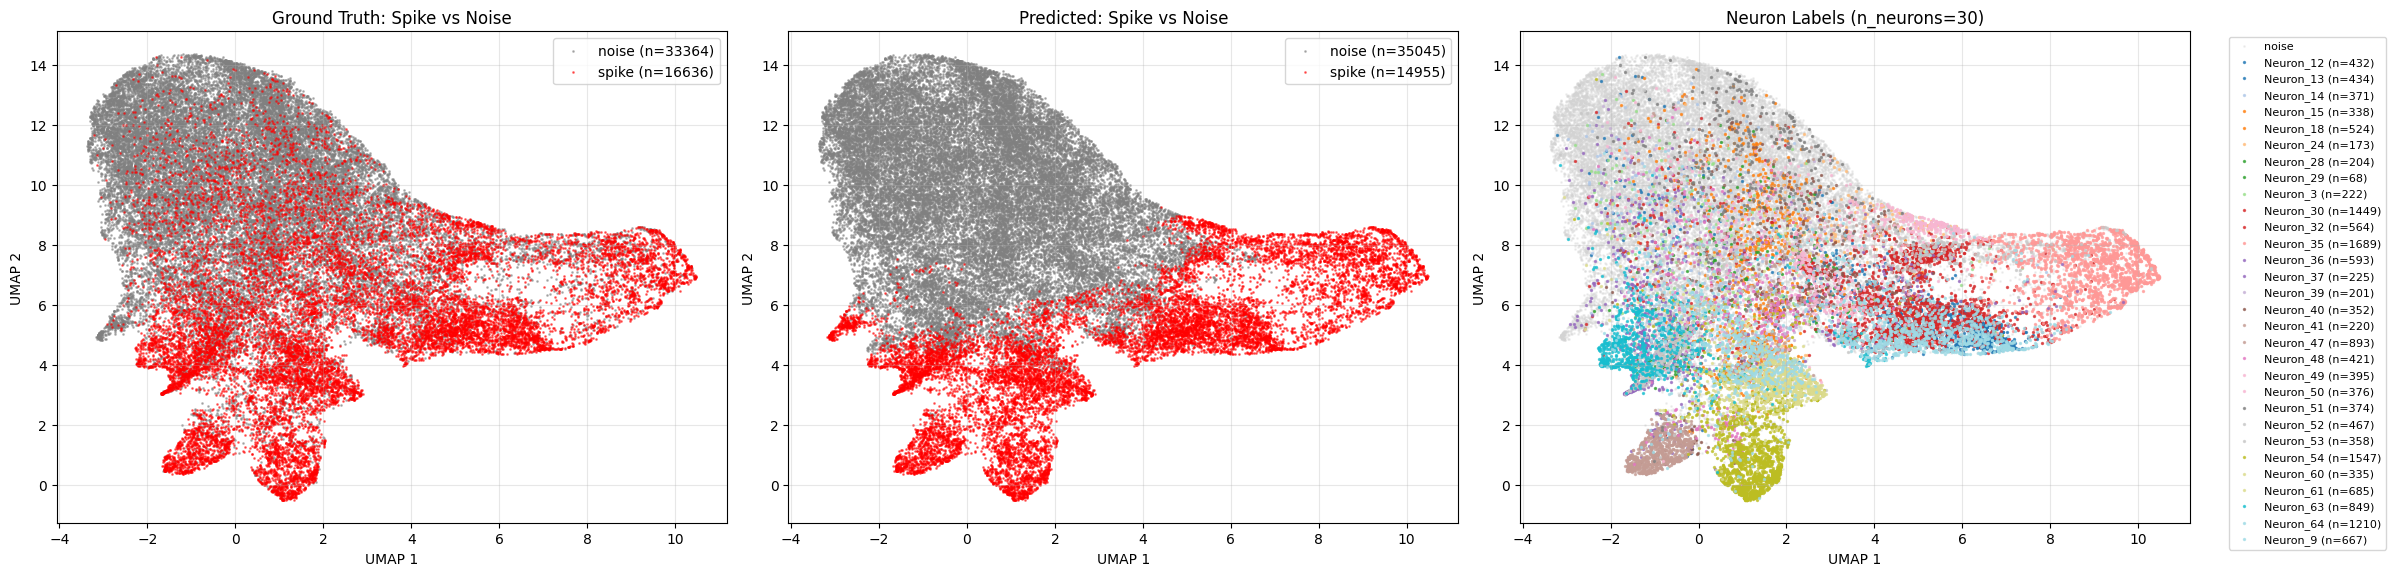


UMAP可视化验证完成！


In [36]:
# UMAP可视化验证：使用way3层特征
print("="*60)
print("UMAP可视化验证（way3层特征）")
print("="*60)

# 准备数据（需要保留neuron标签）
all_features_vis = []  # 存储展平后的特征 (n, 36)
all_labels_gt = []  # 存储GT标签 (0=noise, 1=spike)
all_labels_neuron = []  # 存储neuron标签

tolerance = 1  # 时间容差（与训练时一致）

for group_idx, group_channels in enumerate(channel_groups):
    print(f"\n处理 Group {group_idx} (channels {group_channels})...")
    
    # 检查是否有该group的PC特征
    if group_idx not in group_pc_features:
        print(f"  跳过: Group {group_idx} 没有PC特征数据")
        continue
    
    pc_features = group_pc_features[group_idx]  # (n_potential_spikes, n_channels, n_pcs) = (n, 6, 6)
    threshold_times = np.array(threshold_results[group_idx])
    
    if len(pc_features) == 0:
        print(f"  跳过: Group {group_idx} 没有数据")
        continue
    
    # 获取该group对应的neuron
    neurons_in_group = channel_group_to_neurons[group_idx]
    
    if len(neurons_in_group) == 0:
        print(f"  跳过: Group {group_idx} 没有对应的neuron")
        continue
    
    # 获取GT spike的时间点和neuron标签
    if 'neuron' not in spike_inf_filtered.columns:
        print(f"  跳过: spike_inf_filtered中没有'neuron'列")
        continue
    
    gt_data = spike_inf_filtered[spike_inf_filtered['neuron'].isin(neurons_in_group)]
    gt_times = gt_data['time'].values
    gt_neurons = gt_data['neuron'].values
    
    # 匹配GT spike，确定哪些是spike（匹配到GT的）和noise（未匹配的）
    is_spike = np.zeros(len(pc_features), dtype=bool)
    neuron_labels = np.full(len(pc_features), 'noise', dtype=object)
    used_detected_indices = set()
    
    # 为每个GT spike找到匹配的检测结果
    for gt_idx in range(len(gt_times)):
        gt_time = gt_times[gt_idx]
        gt_neuron = gt_neurons[gt_idx]
        
        distances = np.abs(threshold_times - gt_time)
        matched_indices = np.where(distances <= tolerance)[0]
        available_indices = [idx for idx in matched_indices if idx not in used_detected_indices]
        
        if len(available_indices) > 0:
            best_idx = available_indices[np.argmin(distances[available_indices])]
            is_spike[best_idx] = True
            neuron_labels[best_idx] = gt_neuron
            used_detected_indices.add(best_idx)
    
    n_spikes_detected = np.sum(is_spike)
    n_noise_detected = len(is_spike) - n_spikes_detected
    print(f"  匹配到的spike数量: {n_spikes_detected}")
    print(f"  noise数量: {n_noise_detected}")
    
    # 展平PC特征: (n, 6, 6) -> (n, 36)
    pc_features_flat = pc_features.reshape(len(pc_features), -1)  # (n, 36)
    
    # 提取所有GT spike
    spike_features = pc_features_flat[is_spike]  # (n_spikes, 36)
    spike_labels_gt = np.ones(len(spike_features), dtype=np.int64)  # 1 = spike
    spike_labels_neuron = neuron_labels[is_spike]  # neuron标签
    
    # 提取2倍量的noise（与训练时一致）
    noise_mask = ~is_spike
    noise_features_all = pc_features_flat[noise_mask]  # (n_noise_all, 36)
    noise_labels_neuron_all = neuron_labels[noise_mask]  # 都是'noise'
    
    n_noise_needed = min(2 * len(spike_features), len(noise_features_all))
    if n_noise_needed < len(noise_features_all):
        # 随机选择2倍量的noise（使用固定随机种子以确保可重复）
        np.random.seed(42)
        noise_indices = np.random.choice(len(noise_features_all), n_noise_needed, replace=False)
        noise_features = noise_features_all[noise_indices]
        noise_labels_neuron = noise_labels_neuron_all[noise_indices]
    else:
        # 如果noise数量不足2倍，使用所有noise
        noise_features = noise_features_all
        noise_labels_neuron = noise_labels_neuron_all
        print(f"  警告: noise数量({len(noise_features_all)})不足2倍spike数量({len(spike_features)}), 使用所有noise")
    
    noise_labels_gt = np.zeros(len(noise_features), dtype=np.int64)  # 0 = noise
    
    # 合并spike和noise
    group_features = np.concatenate([spike_features, noise_features], axis=0)  # (n_spikes + n_noise, 36)
    group_labels_gt = np.concatenate([spike_labels_gt, noise_labels_gt], axis=0)  # (n_spikes + n_noise,)
    group_labels_neuron = np.concatenate([spike_labels_neuron, noise_labels_neuron], axis=0)  # (n_spikes + n_noise,)
    
    # 添加到总数据中
    all_features_vis.append(group_features)
    all_labels_gt.append(group_labels_gt)
    all_labels_neuron.append(group_labels_neuron)
    
    print(f"  提取的spike数量: {len(spike_features)}")
    print(f"  提取的noise数量: {len(noise_features)}")
    print(f"  该group总数据量: {len(group_features)}")

# 合并所有group的数据
all_features_vis = np.concatenate(all_features_vis, axis=0)  # (N, 36)
all_labels_gt = np.concatenate(all_labels_gt, axis=0)  # (N,)
all_labels_neuron = np.concatenate(all_labels_neuron, axis=0)  # (N,)

print(f"\n所有group合并后:")
print(f"  总数据量: {len(all_features_vis)}")
print(f"  Spike数量: {np.sum(all_labels_gt == 1)}")
print(f"  Noise数量: {np.sum(all_labels_gt == 0)}")
print(f"  特征形状: {all_features_vis.shape}")

# 使用模型提取way3层特征
print(f"\n提取way3层特征...")
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 批量提取特征（避免内存问题）
batch_size = 1024
all_way3_features = []

with torch.no_grad():
    for i in range(0, len(all_features_vis), batch_size):
        batch_features = torch.FloatTensor(all_features_vis[i:i+batch_size]).to(device)
        way3_features = model.intermediate_forward(batch_features)  # (batch_size, 16)
        all_way3_features.append(way3_features.cpu().numpy())

all_way3_features = np.concatenate(all_way3_features, axis=0)  # (N, 16)
print(f"way3层特征形状: {all_way3_features.shape}")

# 进行预测（用于绘制predicted图）
print(f"\n进行预测...")
all_pred_logits = []
all_pred_probs = []

with torch.no_grad():
    for i in range(0, len(all_features_vis), batch_size):
        batch_features = torch.FloatTensor(all_features_vis[i:i+batch_size]).to(device)
        batch_logits = model(batch_features).squeeze()  # (batch_size,)
        batch_probs = torch.sigmoid(batch_logits)  # (batch_size,)
        
        all_pred_logits.append(batch_logits.cpu().numpy())
        all_pred_probs.append(batch_probs.cpu().numpy())

all_pred_probs = np.concatenate(all_pred_probs, axis=0)
all_pred_labels = (all_pred_probs > 0.5).astype(np.int64)  # 阈值0.5

print(f"预测完成: Spike预测数量={np.sum(all_pred_labels == 1)}, Noise预测数量={np.sum(all_pred_labels == 0)}")

# 随机采样50000个点
n_samples = 50000
n_total = len(all_way3_features)
if n_total > n_samples:
    np.random.seed(42)
    sample_indices = np.random.choice(n_total, n_samples, replace=False)
else:
    sample_indices = np.arange(n_total)

sampled_way3_features = all_way3_features[sample_indices]
sampled_labels_gt = all_labels_gt[sample_indices]
sampled_labels_pred = all_pred_labels[sample_indices]
sampled_labels_neuron = all_labels_neuron[sample_indices]

print(f"\n采样 {len(sample_indices)} 个点用于UMAP可视化")

# UMAP降维
print(f"进行UMAP降维...")
umap_model = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_embedding = umap_model.fit_transform(sampled_way3_features)

print(f"UMAP降维完成: {umap_embedding.shape}")

# 绘制三个图
print(f"\n绘制可视化图...")
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# 图1: Ground Truth (spike/noise)
ax1 = axes[0]
noise_mask_gt = sampled_labels_gt == 0
spike_mask_gt = sampled_labels_gt == 1

ax1.scatter(umap_embedding[noise_mask_gt, 0], umap_embedding[noise_mask_gt, 1], 
            c='gray', label=f'noise (n={np.sum(noise_mask_gt)})', 
            alpha=0.5, s=1)
ax1.scatter(umap_embedding[spike_mask_gt, 0], umap_embedding[spike_mask_gt, 1], 
            c='red', label=f'spike (n={np.sum(spike_mask_gt)})', 
            alpha=0.5, s=1)
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.set_title('Ground Truth: Spike vs Noise')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2: Predicted (spike/noise)
ax2 = axes[1]
noise_mask_pred = sampled_labels_pred == 0
spike_mask_pred = sampled_labels_pred == 1

ax2.scatter(umap_embedding[noise_mask_pred, 0], umap_embedding[noise_mask_pred, 1], 
            c='gray', label=f'noise (n={np.sum(noise_mask_pred)})', 
            alpha=0.5, s=1)
ax2.scatter(umap_embedding[spike_mask_pred, 0], umap_embedding[spike_mask_pred, 1], 
            c='red', label=f'spike (n={np.sum(spike_mask_pred)})', 
            alpha=0.5, s=1)
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('Predicted: Spike vs Noise')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 图3: Neuron标签
ax3 = axes[2]
unique_neurons = np.unique(sampled_labels_neuron)
unique_neurons = [n for n in unique_neurons if n != 'noise']

# 为每个neuron分配颜色
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_neurons)))
neuron_color_map = {neuron: colors[i] for i, neuron in enumerate(unique_neurons)}

# 绘制noise
noise_mask_neuron = sampled_labels_neuron == 'noise'
ax3.scatter(umap_embedding[noise_mask_neuron, 0], umap_embedding[noise_mask_neuron, 1], 
            c='lightgray', label='noise', alpha=0.3, s=1)

# 绘制各个neuron
for neuron in unique_neurons:
    neuron_mask = sampled_labels_neuron == neuron
    if np.sum(neuron_mask) > 0:
        ax3.scatter(umap_embedding[neuron_mask, 0], umap_embedding[neuron_mask, 1], 
                   c=[neuron_color_map[neuron]], label=f'{neuron} (n={np.sum(neuron_mask)})', 
                   alpha=0.7, s=2)

ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.set_title(f'Neuron Labels (n_neurons={len(unique_neurons)})')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()

# 保存图片
save_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/test_22522_umap_validation.pdf"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nUMAP可视化图已保存到: {save_path}")

plt.show()

print(f"\nUMAP可视化验证完成！")


UMAP可视化分析

处理 Group 0 (channels [1, 3, 5, 7, 9, 11])...
  总数据点数量: 132774
  PC特征形状: (132774, 6, 6) -> 展平后: (132774, 36)
  匹配到的spike数量: 13808
  noise数量: 118966
  抽取 20000 个点用于UMAP可视化
  进行UMAP降维...


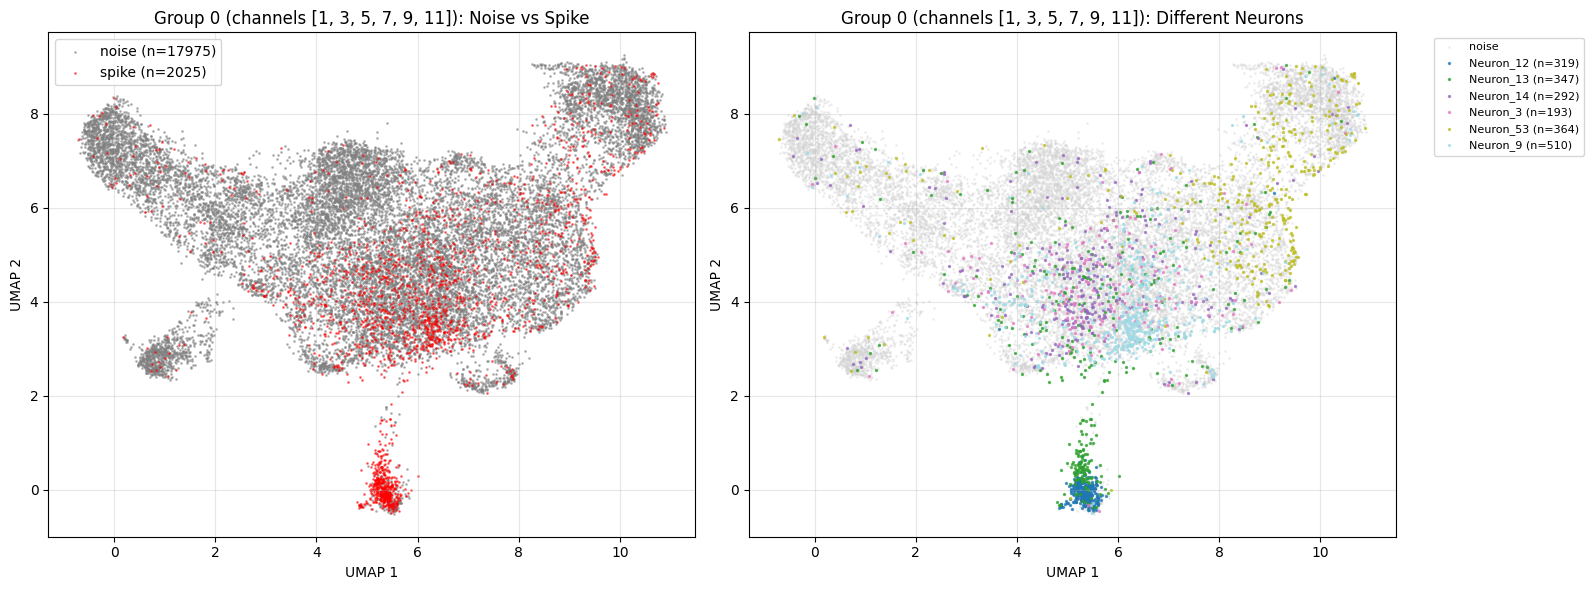

  UMAP可视化图已保存
  不同neuron数量: 6

处理 Group 1 (channels [0, 2, 4, 6, 8, 10])...
  总数据点数量: 134631
  PC特征形状: (134631, 6, 6) -> 展平后: (134631, 36)
  匹配到的spike数量: 6813
  noise数量: 127818
  抽取 20000 个点用于UMAP可视化
  进行UMAP降维...


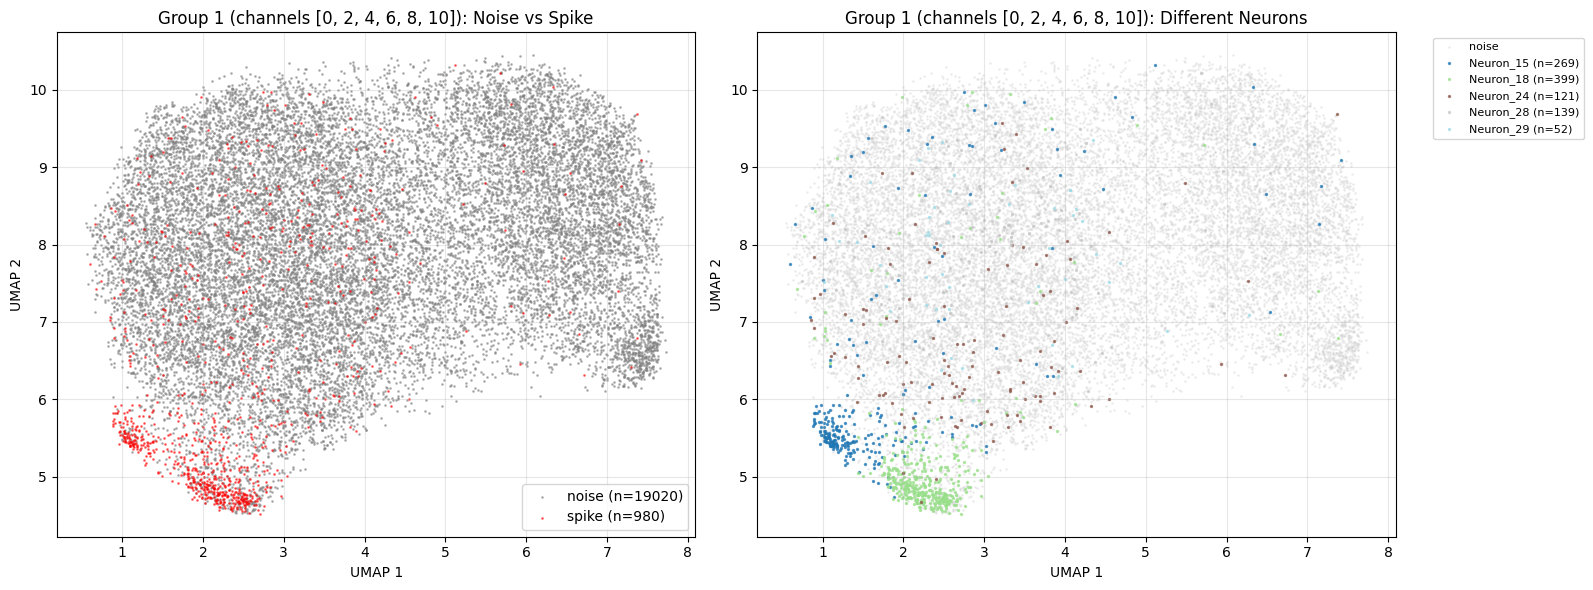

  UMAP可视化图已保存
  不同neuron数量: 5

处理 Group 2 (channels [13, 15, 17, 19, 21, 23])...
  总数据点数量: 143485
  PC特征形状: (143485, 6, 6) -> 展平后: (143485, 36)
  匹配到的spike数量: 23376
  noise数量: 120109
  抽取 20000 个点用于UMAP可视化
  进行UMAP降维...


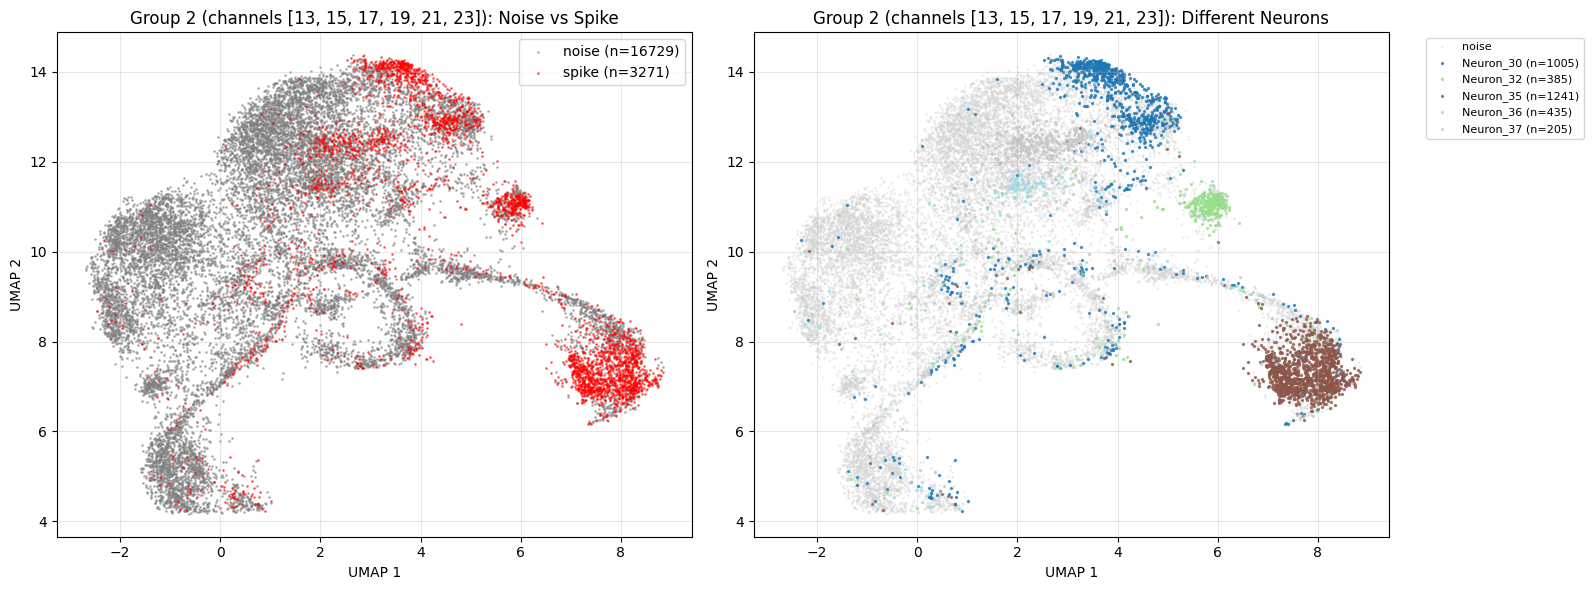

  UMAP可视化图已保存
  不同neuron数量: 5

处理 Group 3 (channels [24, 25, 26, 27, 28, 29])...
  总数据点数量: 142010
  PC特征形状: (142010, 6, 6) -> 展平后: (142010, 36)
  匹配到的spike数量: 19901
  noise数量: 122109
  抽取 20000 个点用于UMAP可视化
  进行UMAP降维...


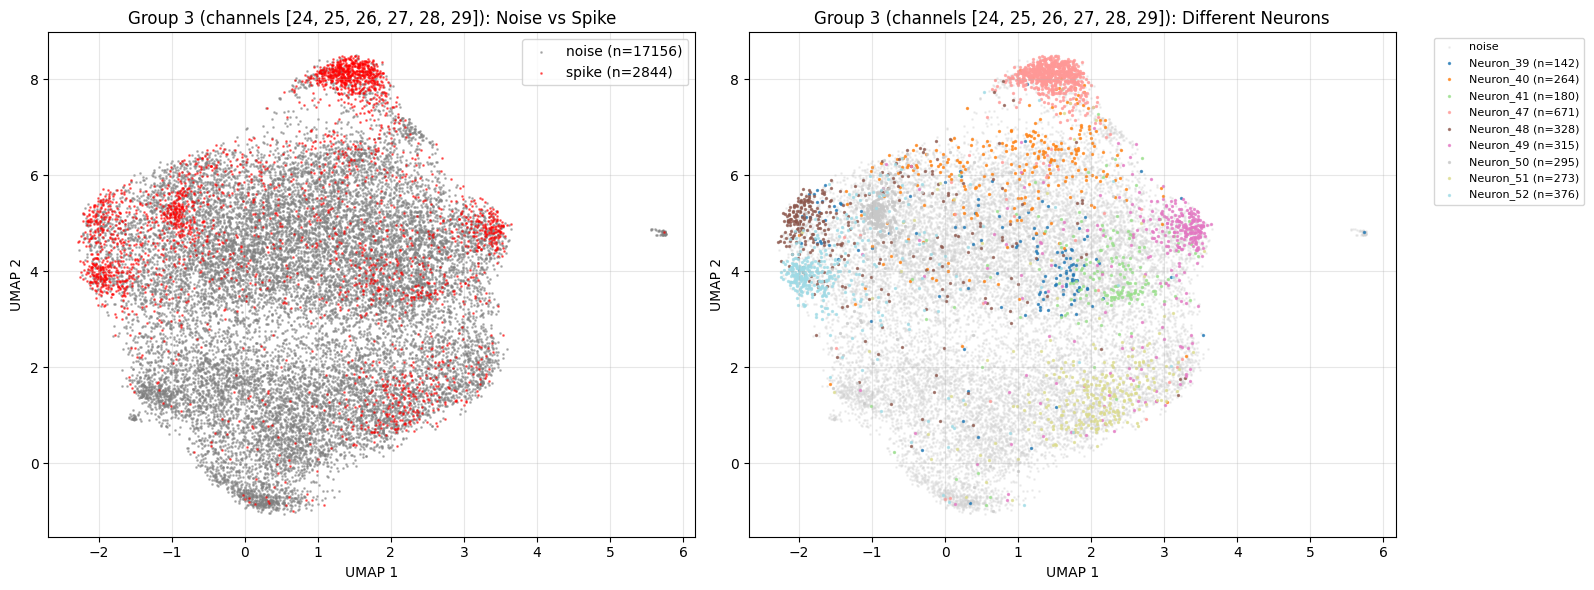

  UMAP可视化图已保存
  不同neuron数量: 9

处理 Group 4 (channels [12, 14, 16, 18, 20, 22])...
  总数据点数量: 128890
  PC特征形状: (128890, 6, 6) -> 展平后: (128890, 36)
  匹配到的spike数量: 24067
  noise数量: 104823
  抽取 20000 个点用于UMAP可视化
  进行UMAP降维...


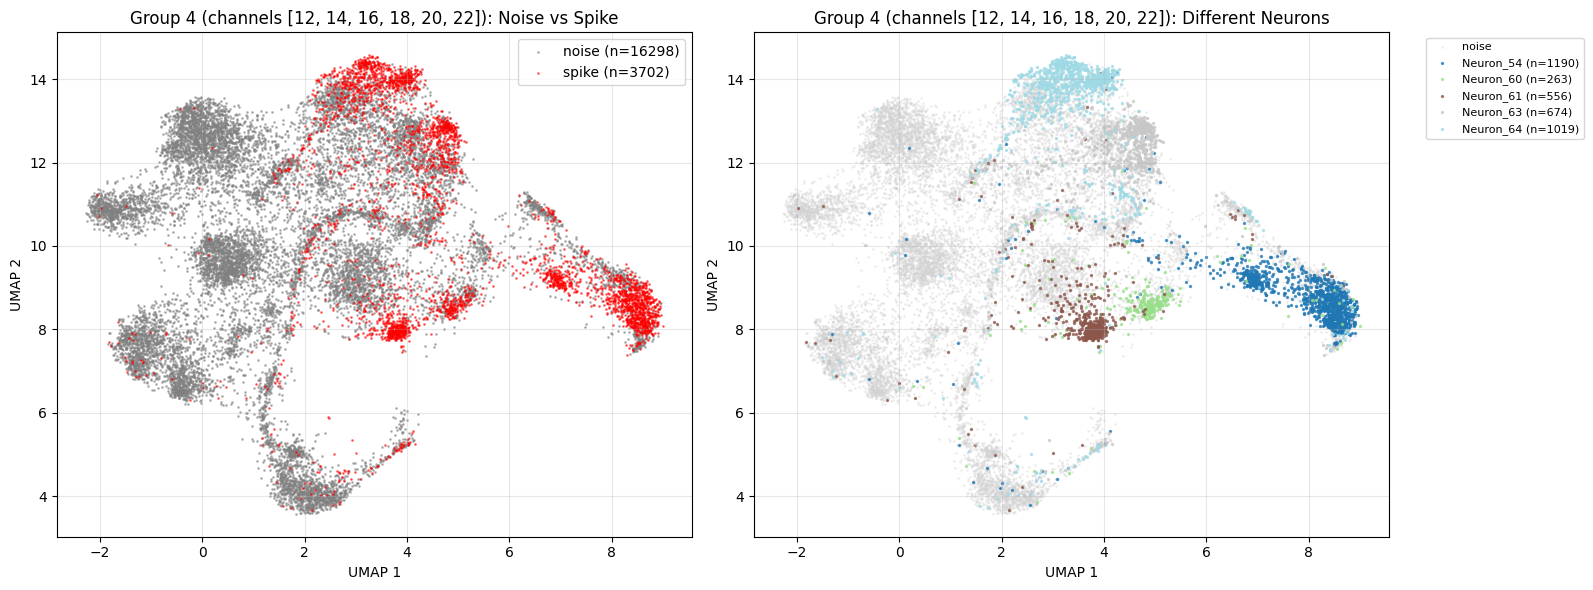

  UMAP可视化图已保存
  不同neuron数量: 5

UMAP可视化完成


In [19]:
# UMAP可视化：分析noise/spike区分以及不同neuron的spike区分
from umap import UMAP
import matplotlib.pyplot as plt

# 对每个group进行UMAP可视化
n_samples = 20000  # 每个group抽取20000个点

print("="*60)
print("UMAP可视化分析")
print("="*60)

for group_idx, group_channels in enumerate(channel_groups):
    print(f"\n处理 Group {group_idx} (channels {group_channels})...")
    
    # 检查是否有该group的PC特征
    if group_idx not in group_pc_features:
        print(f"  跳过: Group {group_idx} 没有PC特征数据")
        continue
    
    pc_features = group_pc_features[group_idx]  # (n_potential_spikes, n_channels, n_pcs)
    threshold_times = np.array(threshold_results[group_idx])
    
    if len(pc_features) == 0:
        print(f"  跳过: Group {group_idx} 没有数据")
        continue
    
    print(f"  总数据点数量: {len(pc_features)}")
    
    # 将PC特征展平：从(n_spikes, n_channels, n_pcs)展平为(n_spikes, n_channels * n_pcs)
    # 每个spike的特征是(6通道, 6PC) = 36维
    n_spikes, n_channels, n_pcs = pc_features.shape
    pc_features_flat = pc_features.reshape(n_spikes, -1)  # (n_spikes, n_channels * n_pcs)
    print(f"  PC特征形状: {pc_features.shape} -> 展平后: {pc_features_flat.shape}")
    
    # 获取该group对应的neuron
    neurons_in_group = channel_group_to_neurons[group_idx]
    
    if len(neurons_in_group) == 0:
        print(f"  跳过: Group {group_idx} 没有对应的neuron")
        continue
    
    # 获取GT spike的时间点
    if 'neuron' not in spike_inf_filtered.columns:
        print(f"  跳过: spike_inf_filtered中没有'Neuron'列")
        continue
    
    gt_times = spike_inf_filtered[spike_inf_filtered['neuron'].isin(neurons_in_group)]['time'].values
    gt_neurons = spike_inf_filtered[spike_inf_filtered['neuron'].isin(neurons_in_group)]['neuron'].values
    
    # 匹配GT spike，确定哪些是spike（匹配到GT的）和noise（未匹配的）
    tolerance = 5
    is_spike = np.zeros(n_spikes, dtype=bool)
    neuron_labels = np.full(n_spikes, 'noise', dtype=object)
    used_detected_indices = set()
    
    # 为每个GT spike找到匹配的检测结果
    for gt_idx in range(len(gt_times)):
        gt_time = gt_times[gt_idx]
        gt_neuron = gt_neurons[gt_idx]
        
        distances = np.abs(threshold_times - gt_time)
        matched_indices = np.where(distances <= tolerance)[0]
        available_indices = [idx for idx in matched_indices if idx not in used_detected_indices]
        
        if len(available_indices) > 0:
            best_idx = available_indices[np.argmin(distances[available_indices])]
            is_spike[best_idx] = True
            neuron_labels[best_idx] = gt_neuron
            used_detected_indices.add(best_idx)
    
    n_spikes_detected = np.sum(is_spike)
    n_noise_detected = n_spikes - n_spikes_detected
    print(f"  匹配到的spike数量: {n_spikes_detected}")
    print(f"  noise数量: {n_noise_detected}")
    
    # 随机抽取n_samples个点
    n_total = len(pc_features_flat)
    if n_total > n_samples:
        sample_indices = np.random.choice(n_total, n_samples, replace=False)
    else:
        sample_indices = np.arange(n_total)
    
    sampled_features = pc_features_flat[sample_indices]
    sampled_is_spike = is_spike[sample_indices]
    sampled_neuron_labels = neuron_labels[sample_indices]
    
    print(f"  抽取 {len(sample_indices)} 个点用于UMAP可视化")
    
    # UMAP降维
    print(f"  进行UMAP降维...")
    umap_model = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embedding = umap_model.fit_transform(sampled_features)
    
    # 绘制两个图：1. noise vs spike；2. 不同neuron的spike
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 图1: noise vs spike
    ax1 = axes[0]
    noise_mask = ~sampled_is_spike
    spike_mask = sampled_is_spike
    
    ax1.scatter(umap_embedding[noise_mask, 0], umap_embedding[noise_mask, 1], 
                c='gray', label=f'noise (n={np.sum(noise_mask)})', 
                alpha=0.5, s=1)
    ax1.scatter(umap_embedding[spike_mask, 0], umap_embedding[spike_mask, 1], 
                c='red', label=f'spike (n={np.sum(spike_mask)})', 
                alpha=0.5, s=1)
    ax1.set_xlabel('UMAP 1')
    ax1.set_ylabel('UMAP 2')
    ax1.set_title(f'Group {group_idx} (channels {group_channels}): Noise vs Spike')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 图2: 不同neuron的spike
    ax2 = axes[1]
    unique_neurons = np.unique(sampled_neuron_labels[sampled_is_spike])
    unique_neurons = [n for n in unique_neurons if n != 'noise']
    
    # 为每个neuron分配颜色
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_neurons)))
    neuron_color_map = {neuron: colors[i] for i, neuron in enumerate(unique_neurons)}
    
    # 绘制noise
    ax2.scatter(umap_embedding[noise_mask, 0], umap_embedding[noise_mask, 1], 
                c='lightgray', label='noise', alpha=0.3, s=1)
    
    # 绘制每个neuron的spike
    for neuron in unique_neurons:
        neuron_mask = (sampled_neuron_labels == neuron) & sampled_is_spike
        if np.sum(neuron_mask) > 0:
            ax2.scatter(umap_embedding[neuron_mask, 0], umap_embedding[neuron_mask, 1], 
                       c=[neuron_color_map[neuron]], label=f'{neuron} (n={np.sum(neuron_mask)})', 
                       alpha=0.7, s=2)
    
    ax2.set_xlabel('UMAP 1')
    ax2.set_ylabel('UMAP 2')
    ax2.set_title(f'Group {group_idx} (channels {group_channels}): Different Neurons')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/test_251121_group{group_idx}_umap.pdf', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"  UMAP可视化图已保存")
    print(f"  不同neuron数量: {len(unique_neurons)}")

print("\n" + "="*60)
print("UMAP可视化完成")
print("="*60)
